<a href="https://www.kaggle.com/code/lalit7881/ai-impact-on-jobs-salaries-2020-26-eda?scriptVersionId=347619546" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/debayank2024/ai-impact-on-jobs-and-salaries-2020-2026/ai_jobs_salaries_clean.csv
/kaggle/input/datasets/debayank2024/ai-impact-on-jobs-and-salaries-2020-2026/data_dictionary.md


## Loading dataset

In [2]:
df = pd.read_csv("/kaggle/input/datasets/debayank2024/ai-impact-on-jobs-and-salaries-2020-2026/ai_jobs_salaries_clean.csv")

In [3]:
df.head()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
0,2025,EX,FT,Head of Data,348516,USD,348516,US,0,US,M,Executive-level,Full-time,On-site,True,Analytics Manager,Information and communications technology serv...
1,2025,EX,FT,Head of Data,232344,USD,232344,US,0,US,M,Executive-level,Full-time,On-site,False,Analytics Manager,Information and communications technology serv...
2,2025,SE,FT,Data Scientist,145400,USD,145400,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
3,2025,SE,FT,Data Scientist,81600,USD,81600,US,0,US,M,Senior-level,Full-time,On-site,False,Data Scientist,"Mathematicians, actuaries and statisticians"
4,2025,MI,FT,Engineer,160000,USD,160000,US,100,US,M,Mid-level,Full-time,Remote,False,Other / Unclassified,NaN


In [4]:
df.tail()

,work_year,experience_level,employment_type,job_title,salary,salary_currency,salary_in_usd,employee_residence,remote_ratio,company_location,company_size,experience_level_label,employment_type_label,work_mode,salary_outlier_flag,role_family,isco_group_hint
71908,2020,SE,FT,Data Scientist,412000,USD,412000,US,100,US,L,Senior-level,Full-time,Remote,True,Data Scientist,"Mathematicians, actuaries and statisticians"
71909,2021,MI,FT,Principal Data Scientist,151000,USD,151000,US,100,US,L,Mid-level,Full-time,Remote,False,Data Scientist,"Mathematicians, actuaries and statisticians"
71910,2020,EN,FT,Data Scientist,105000,USD,105000,US,100,US,S,Entry-level,Full-time,Remote,False,Data Scientist,"Mathematicians, actuaries and statisticians"
71911,2020,EN,CT,Business Data Analyst,100000,USD,100000,US,100,US,L,Entry-level,Contract,Remote,False,Data Analyst,Business services and administration managers
71912,2021,SE,FT,Data Scientist,7000000,INR,94665,IN,50,IN,L,Senior-level,Full-time,Hybrid,False,Data Scientist,"Mathematicians, actuaries and statisticians"


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71913 entries, 0 to 71912
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   work_year               71913 non-null  int64 
 1   experience_level        71913 non-null  object
 2   employment_type         71913 non-null  object
 3   job_title               71913 non-null  object
 4   salary                  71913 non-null  int64 
 5   salary_currency         71913 non-null  object
 6   salary_in_usd           71913 non-null  int64 
 7   employee_residence      71913 non-null  object
 8   remote_ratio            71913 non-null  int64 
 9   company_location        71913 non-null  object
 10  company_size            71913 non-null  object
 11  experience_level_label  71913 non-null  object
 12  employment_type_label   71913 non-null  object
 13  work_mode               71913 non-null  object
 14  salary_outlier_flag     71913 non-null  bool  
 15  ro

In [6]:
df.describe()

,work_year,salary,salary_in_usd,remote_ratio
count,71913.000000,7.191300e+04,71913.000000,71913.000000
mean,2024.425153,1.617102e+05,151161.252625,24.569271
std,0.721198,2.872868e+05,77329.594122,42.917779
min,2020.000000,1.400000e+04,15000.000000,0.000000
25%,2024.000000,9.640000e+04,96000.000000,0.000000
50%,2025.000000,1.397000e+05,138750.000000,0.000000
75%,2025.000000,1.922000e+05,190315.000000,0.000000
max,2025.000000,3.040000e+07,800000.000000,100.000000


In [7]:
df.isnull().sum()

work_year                     0
experience_level              0
employment_type               0
job_title                     0
salary                        0
salary_currency               0
salary_in_usd                 0
employee_residence            0
remote_ratio                  0
company_location              0
company_size                  0
experience_level_label        0
employment_type_label         0
work_mode                     0
salary_outlier_flag           0
role_family                   0
isco_group_hint           40540
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.dtypes

work_year                  int64
experience_level          object
employment_type           object
job_title                 object
salary                     int64
salary_currency           object
salary_in_usd              int64
employee_residence        object
remote_ratio               int64
company_location          object
company_size              object
experience_level_label    object
employment_type_label     object
work_mode                 object
salary_outlier_flag         bool
role_family               object
isco_group_hint           object
dtype: object

In [10]:
df.shape

(71913, 17)

In [11]:
df.nunique()

work_year                     6
experience_level              4
employment_type               4
job_title                   422
salary                    12308
salary_currency              26
salary_in_usd             13580
employee_residence          104
remote_ratio                  3
company_location             97
company_size                  3
experience_level_label        4
employment_type_label         4
work_mode                     3
salary_outlier_flag           2
role_family                  11
isco_group_hint               5
dtype: int64

In [12]:
df.columns

Index(['work_year', 'experience_level', 'employment_type', 'job_title',
       'salary', 'salary_currency', 'salary_in_usd', 'employee_residence',
       'remote_ratio', 'company_location', 'company_size',
       'experience_level_label', 'employment_type_label', 'work_mode',
       'salary_outlier_flag', 'role_family', 'isco_group_hint'],
      dtype='object')

## EDA

DATASET INFORMATION

Shape: (71913, 17)

Columns:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'experience_level_label', 'employment_type_label', 'work_mode', 'salary_outlier_flag', 'role_family', 'isco_group_hint']

Data Types:
work_year                  int64
experience_level          object
employment_type           object
job_title                 object
salary                     int64
salary_currency           object
salary_in_usd              int64
employee_residence        object
remote_ratio               int64
company_location          object
company_size              object
experience_level_label    object
employment_type_label     object
work_mode                 object
salary_outlier_flag         bool
role_family               object
isco_group_hint           object
dtype: object

Missing Values:
work_year                     0
experi

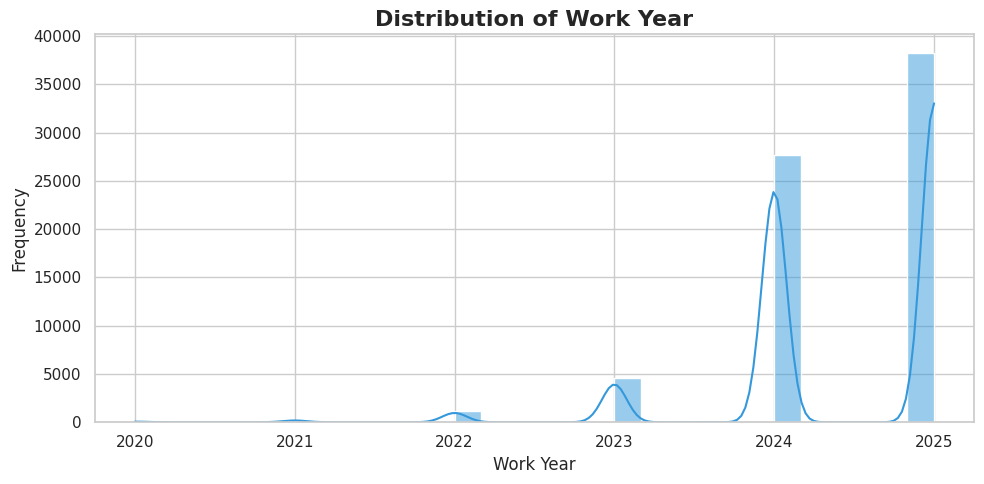

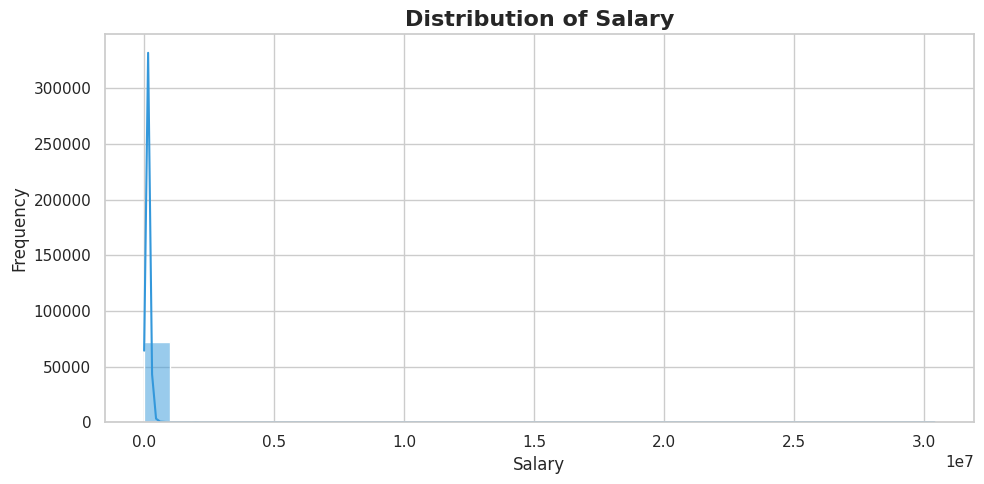

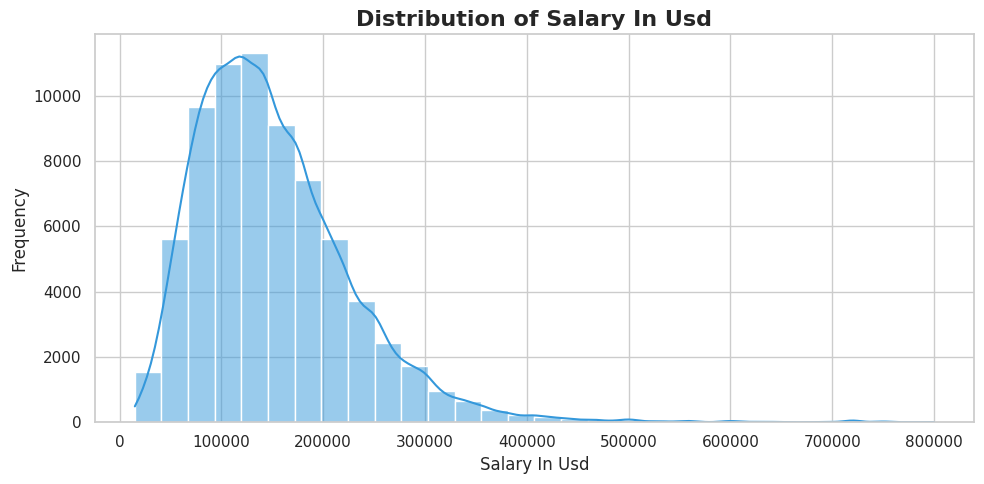

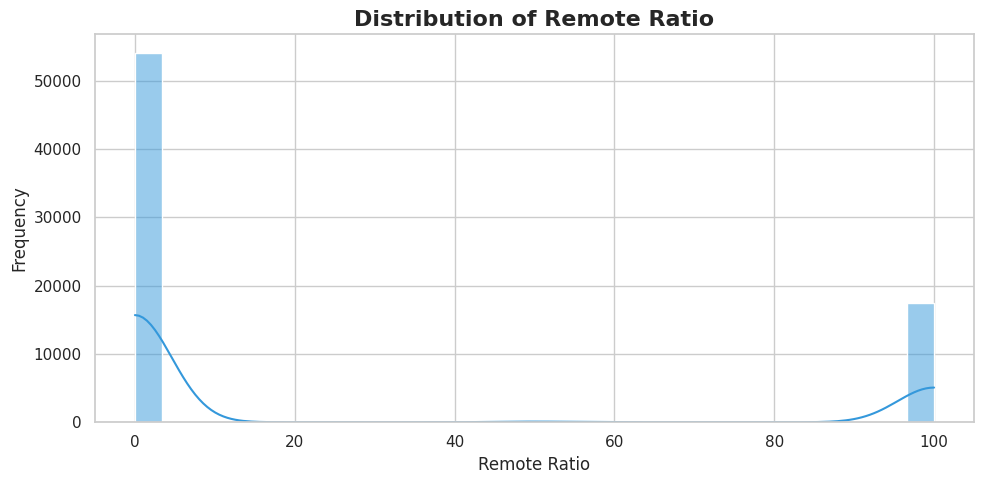

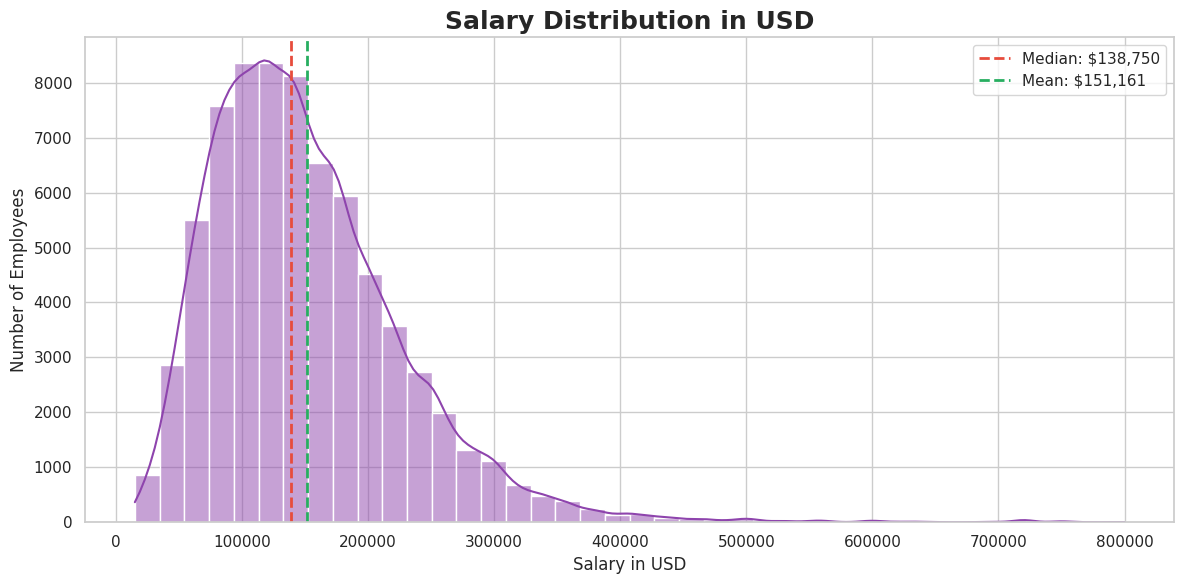

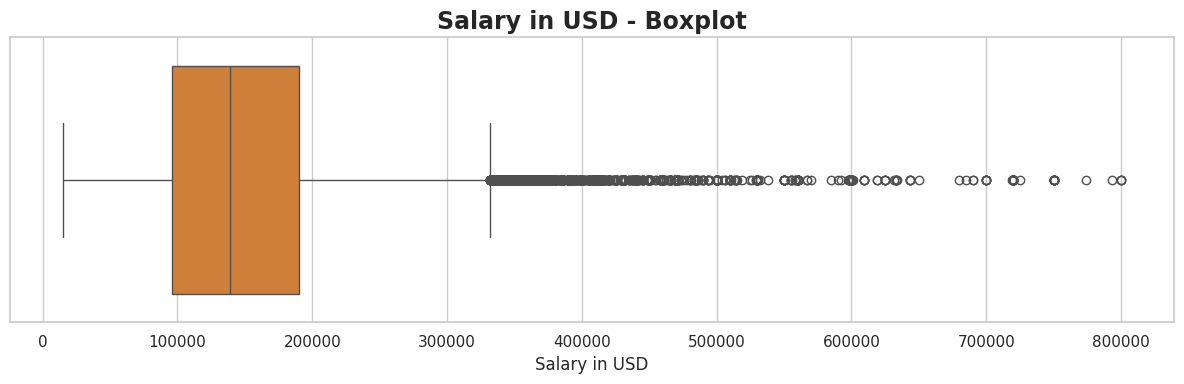

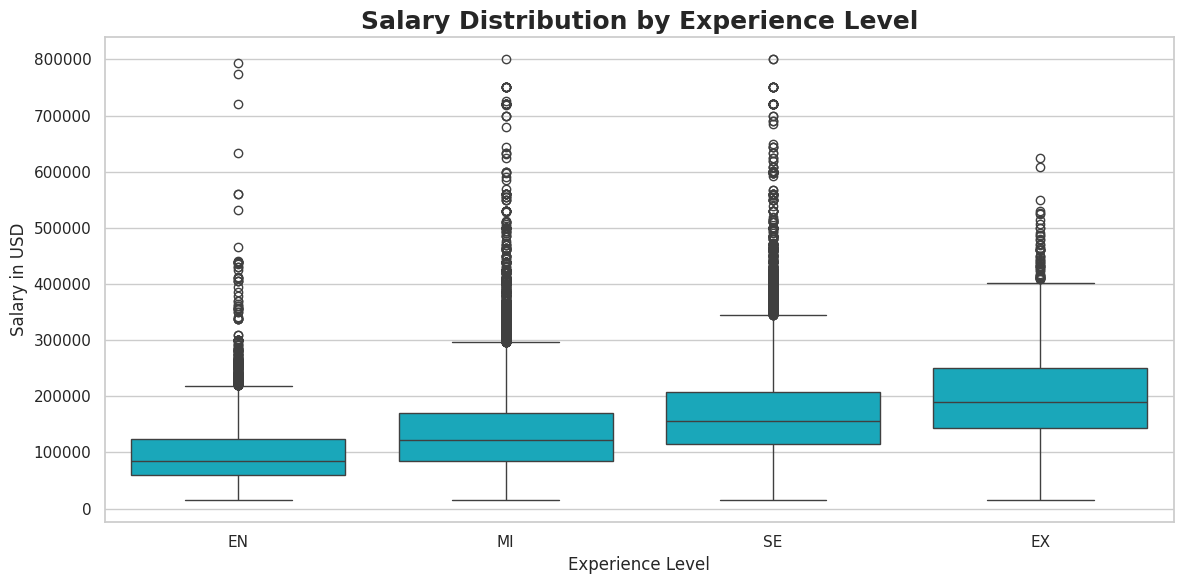

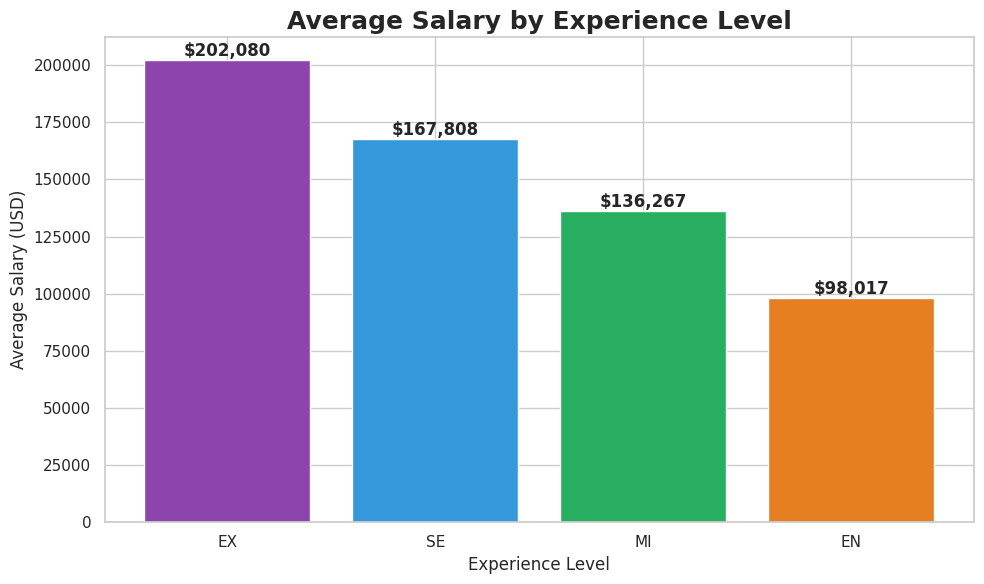

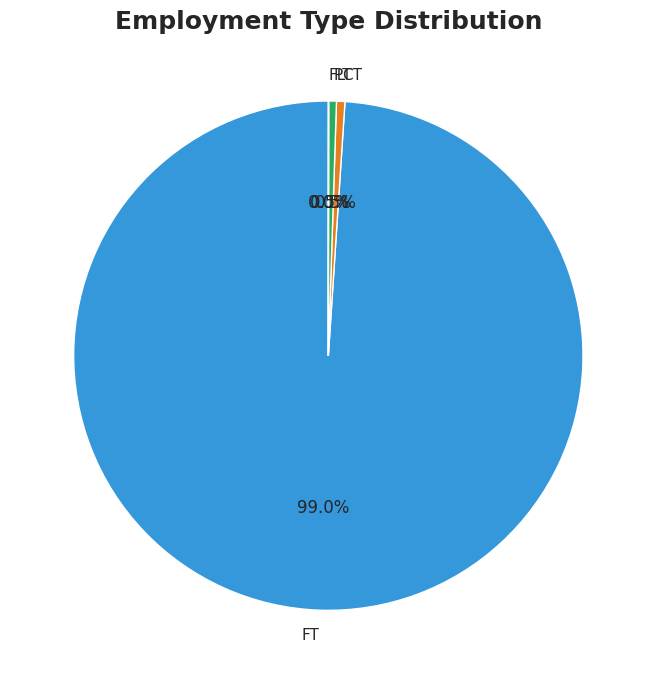

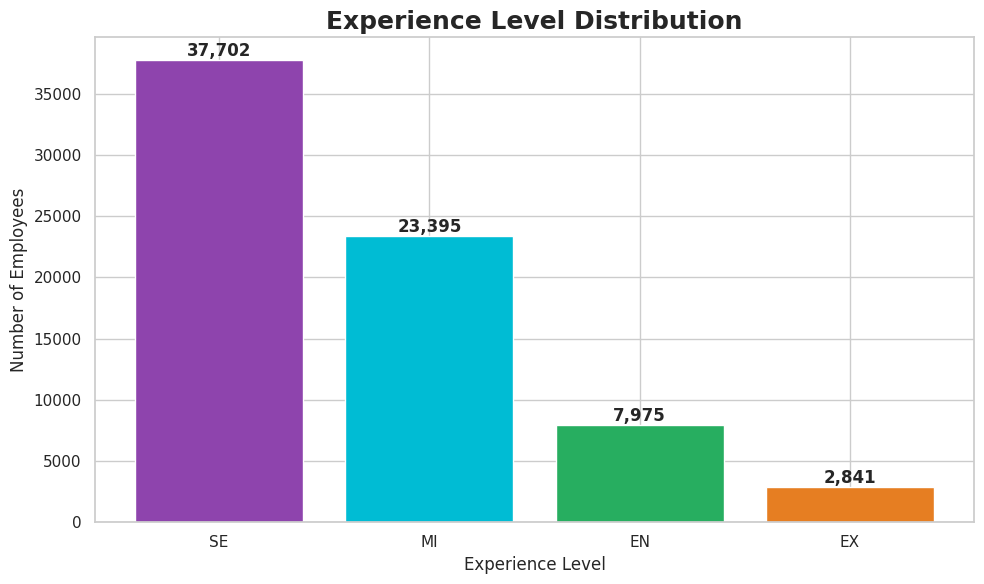

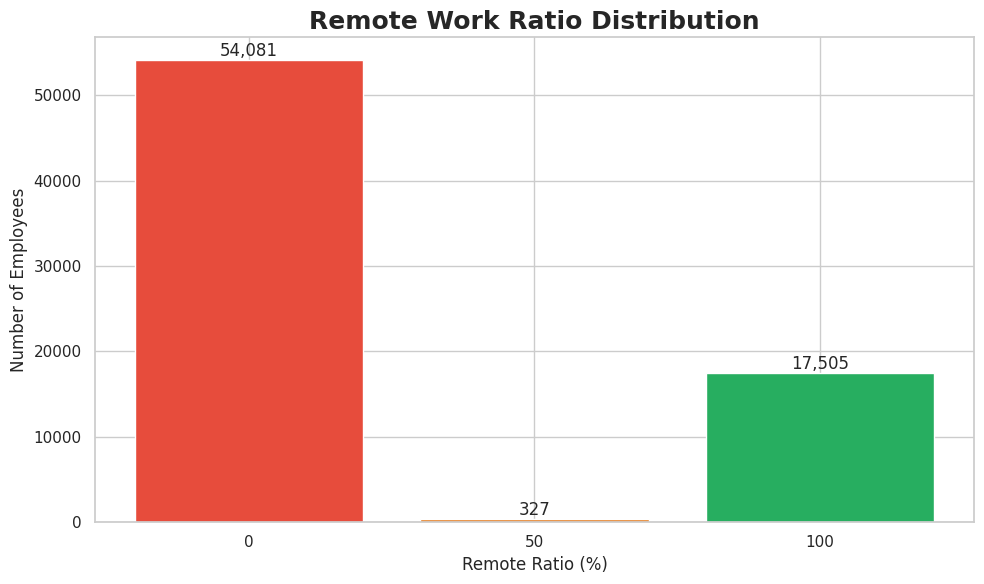

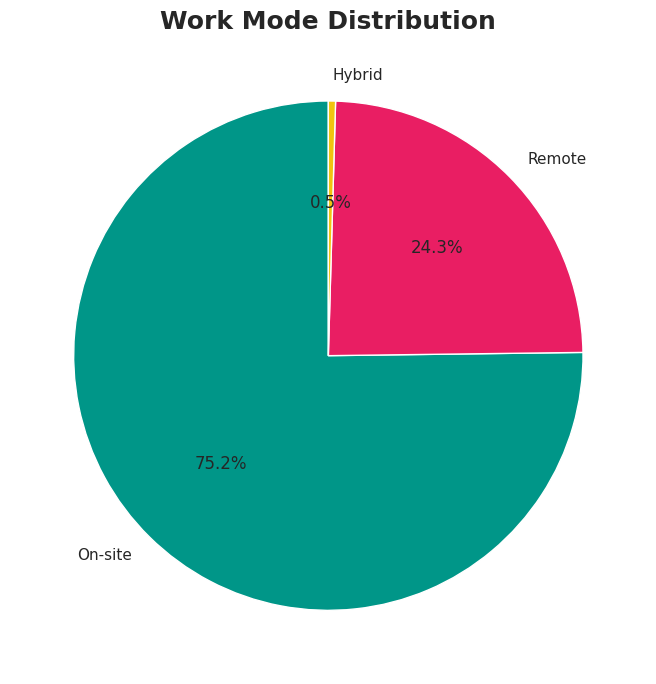

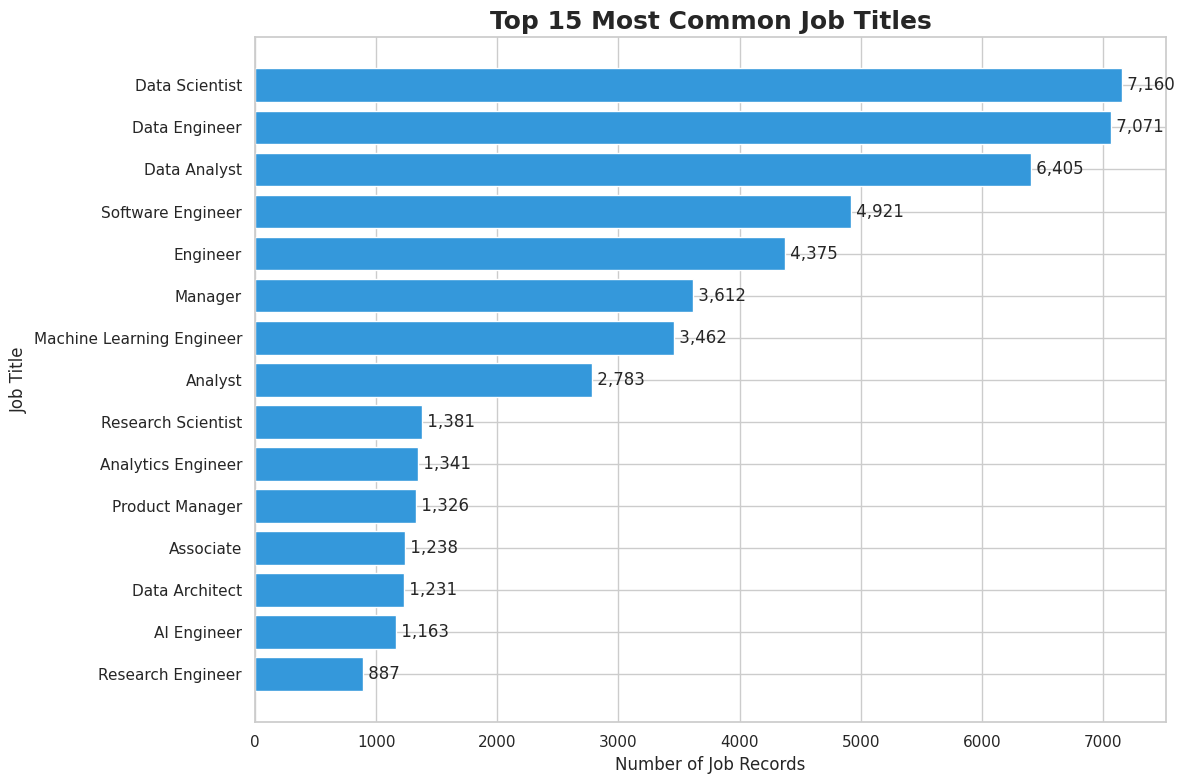

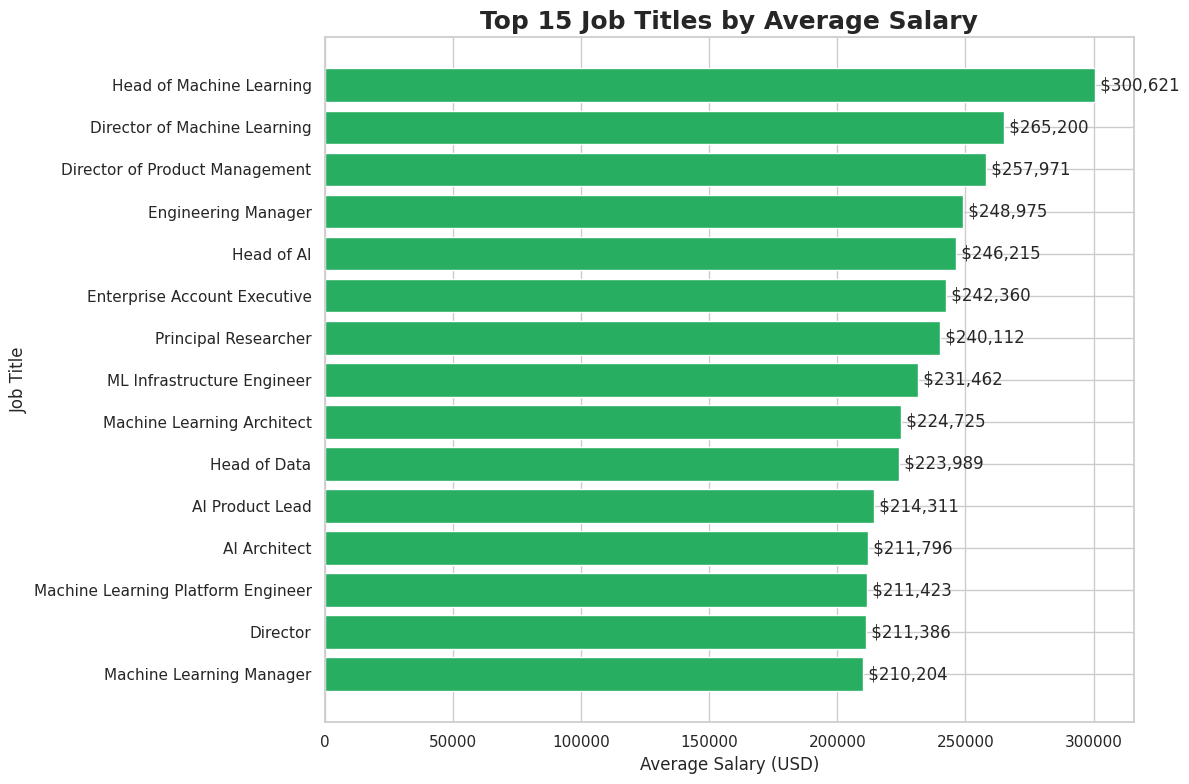

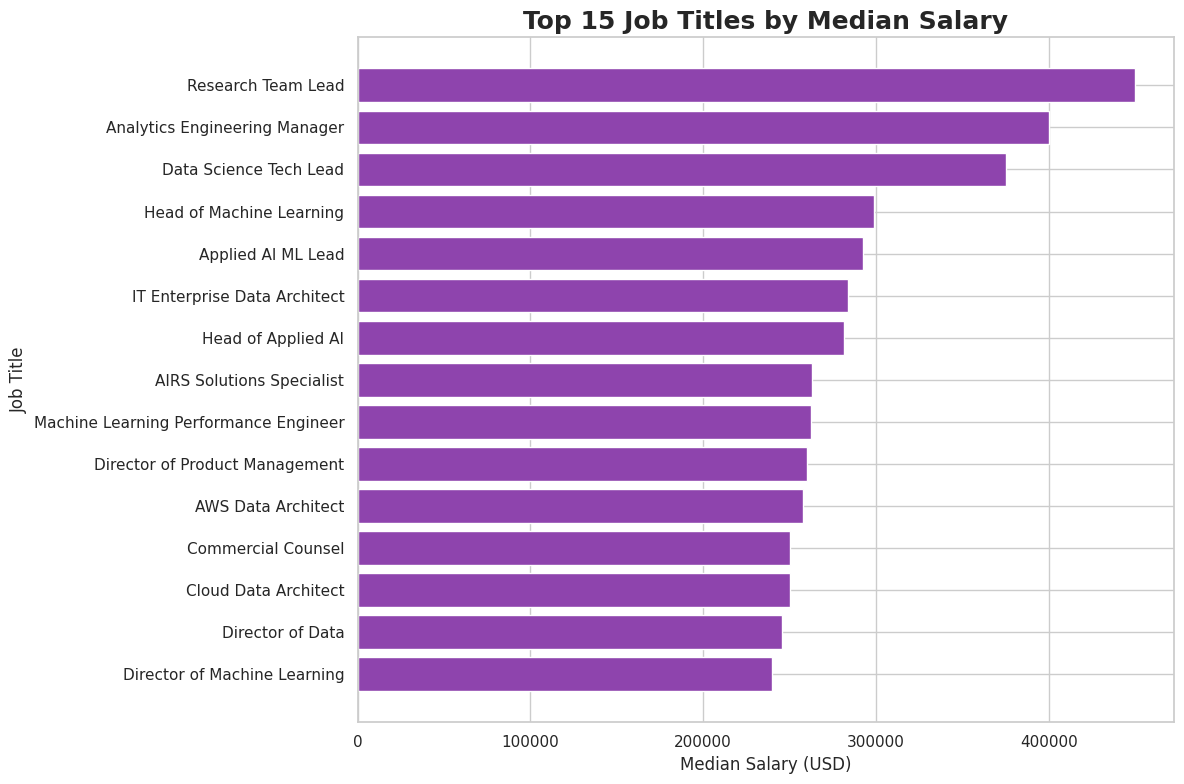

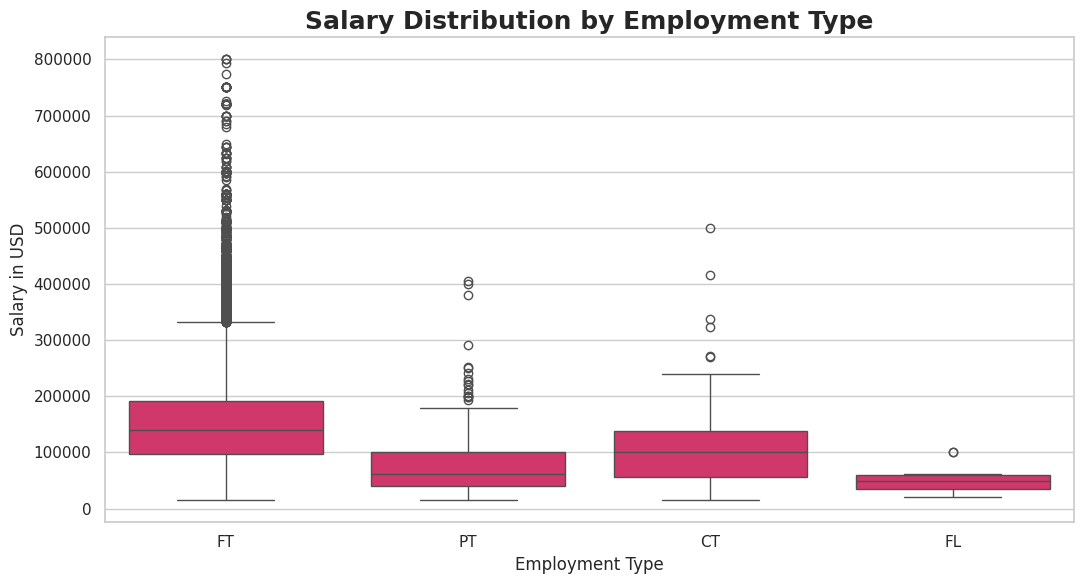

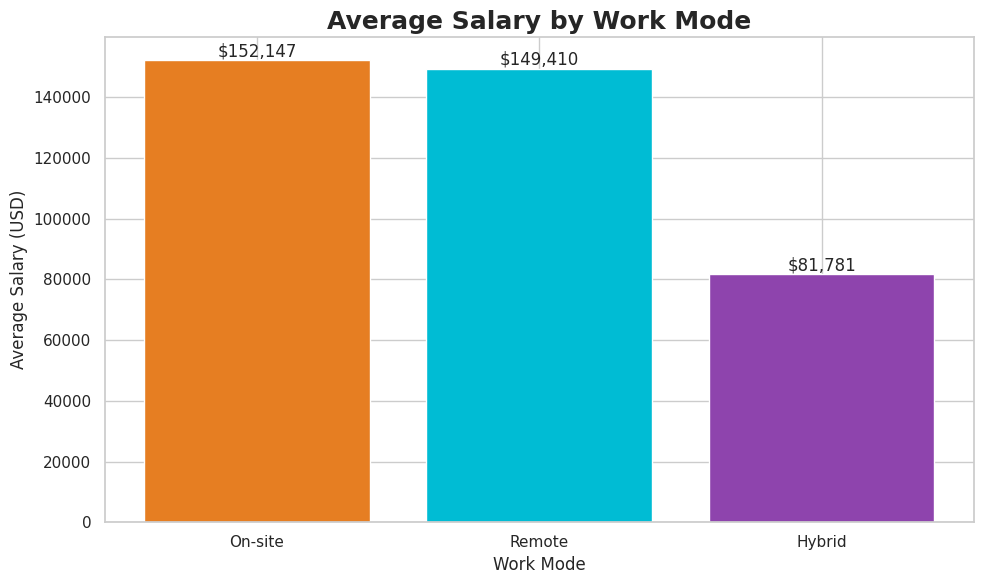

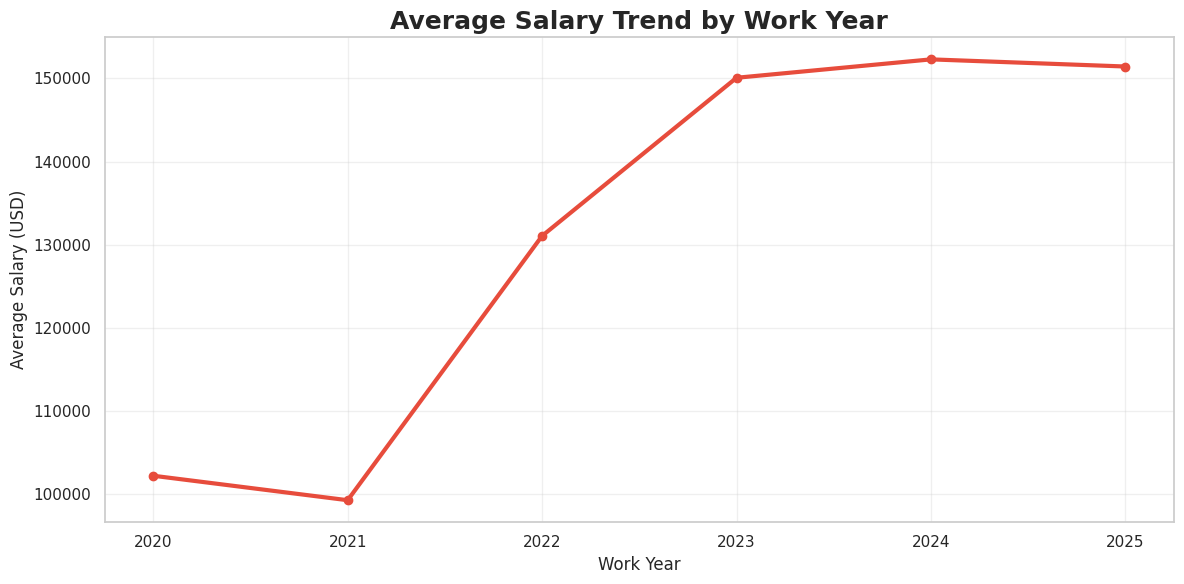

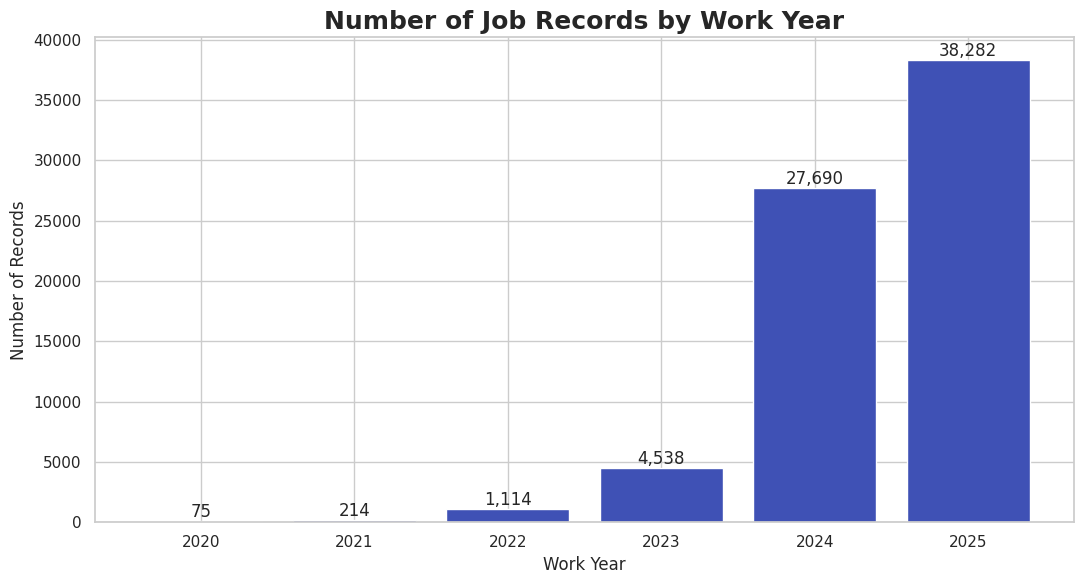

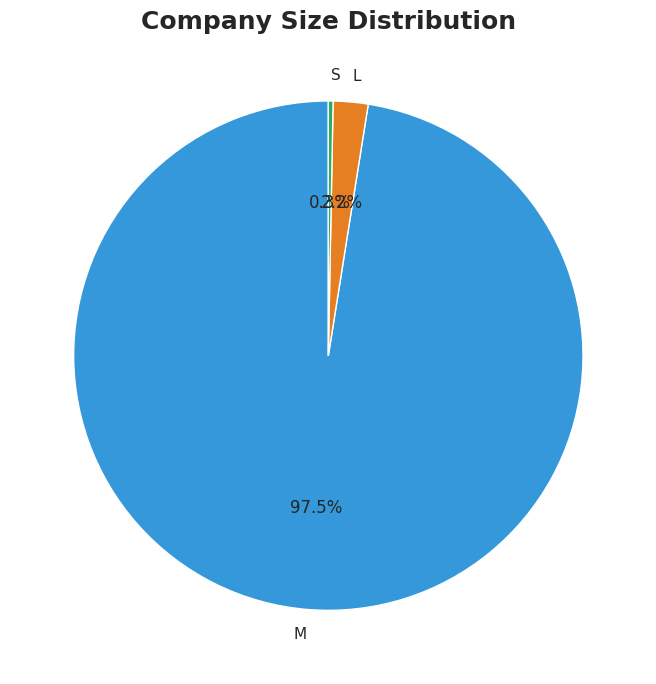

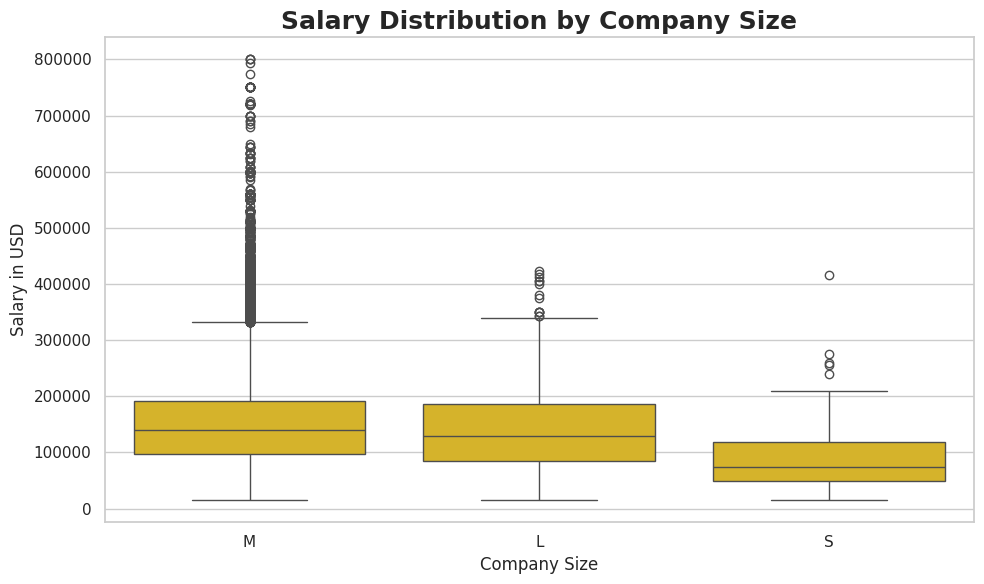

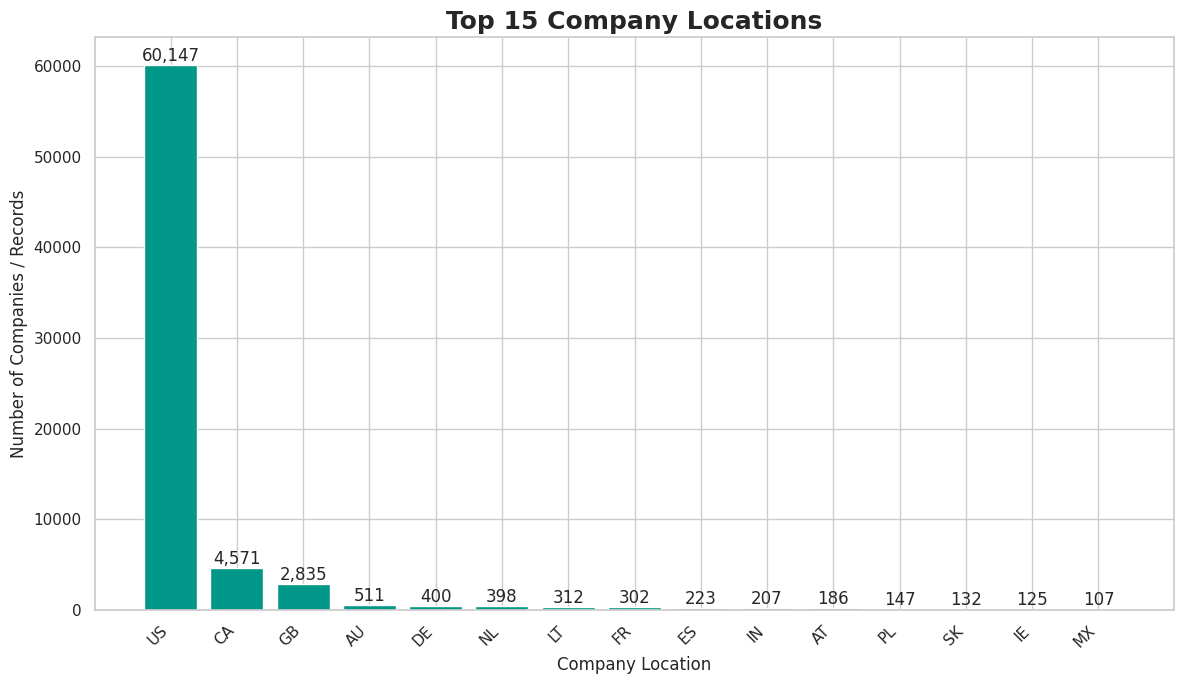

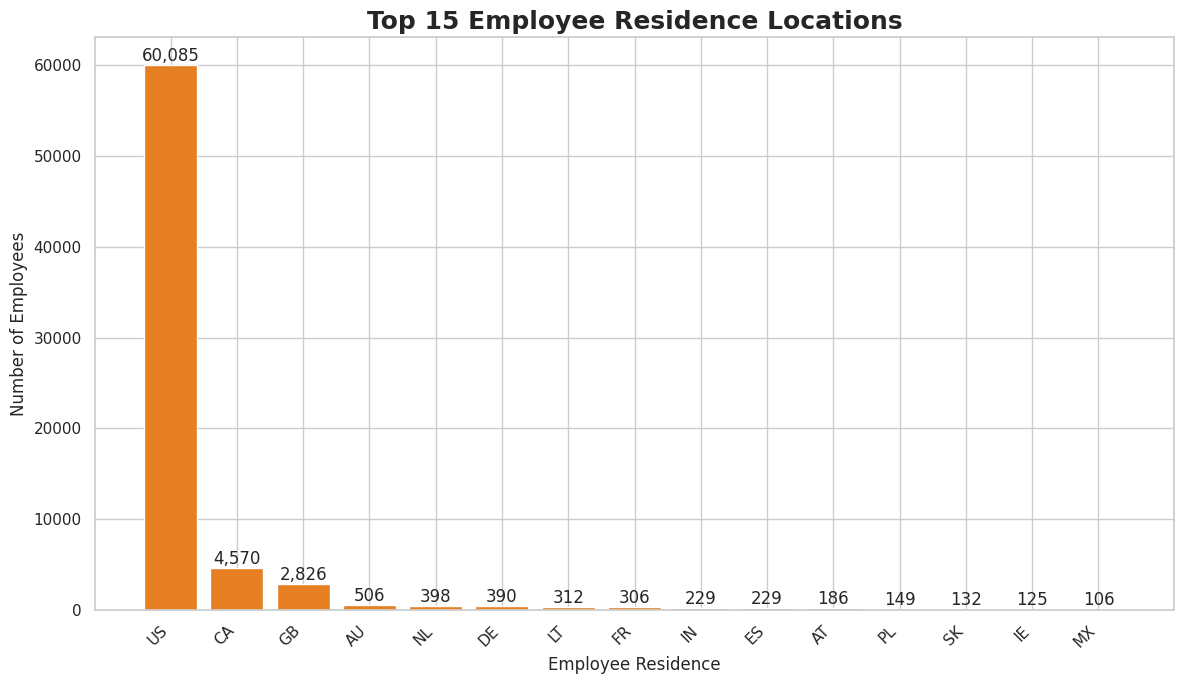

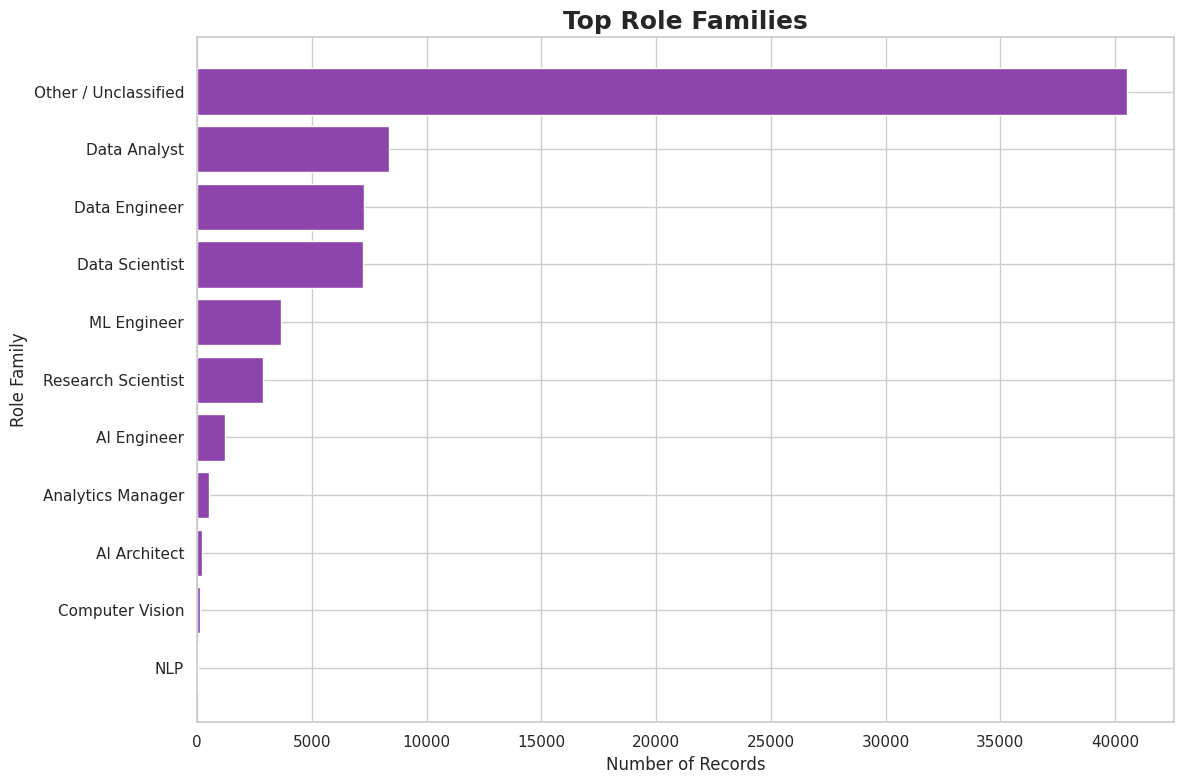

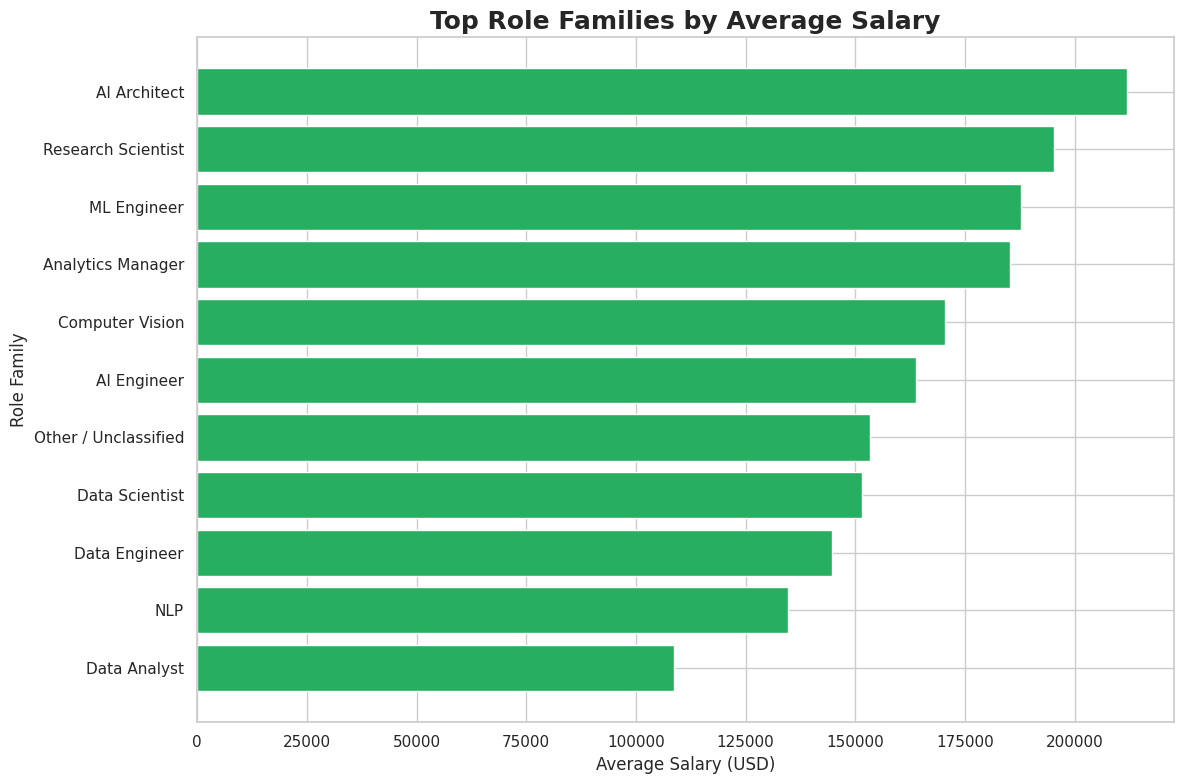

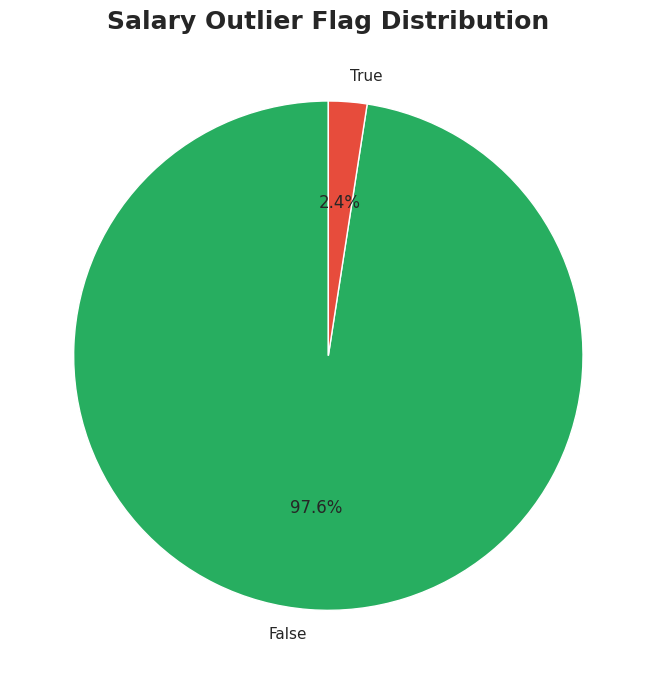

<Figure size 1100x600 with 0 Axes>

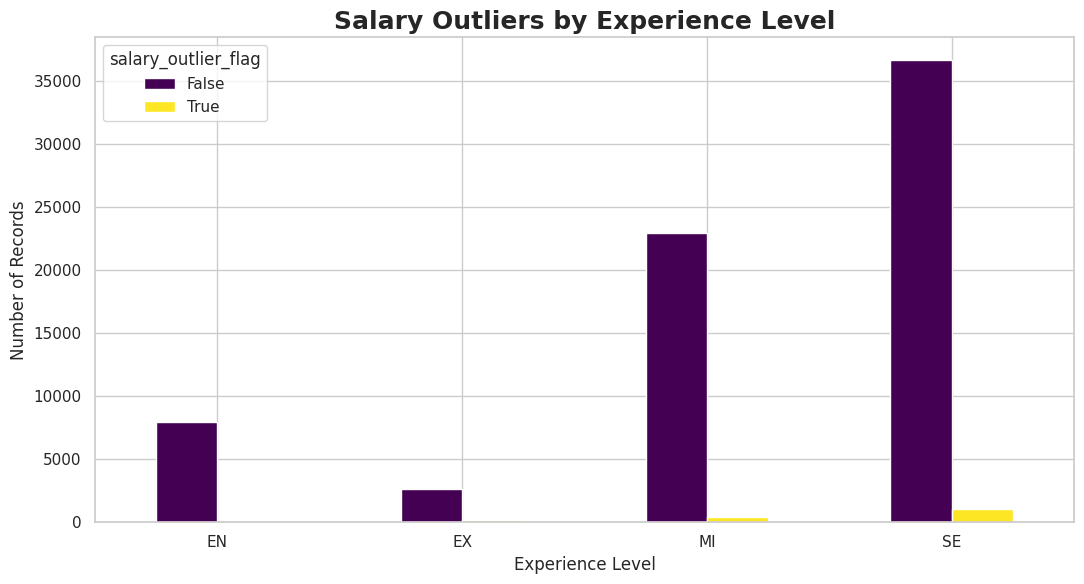

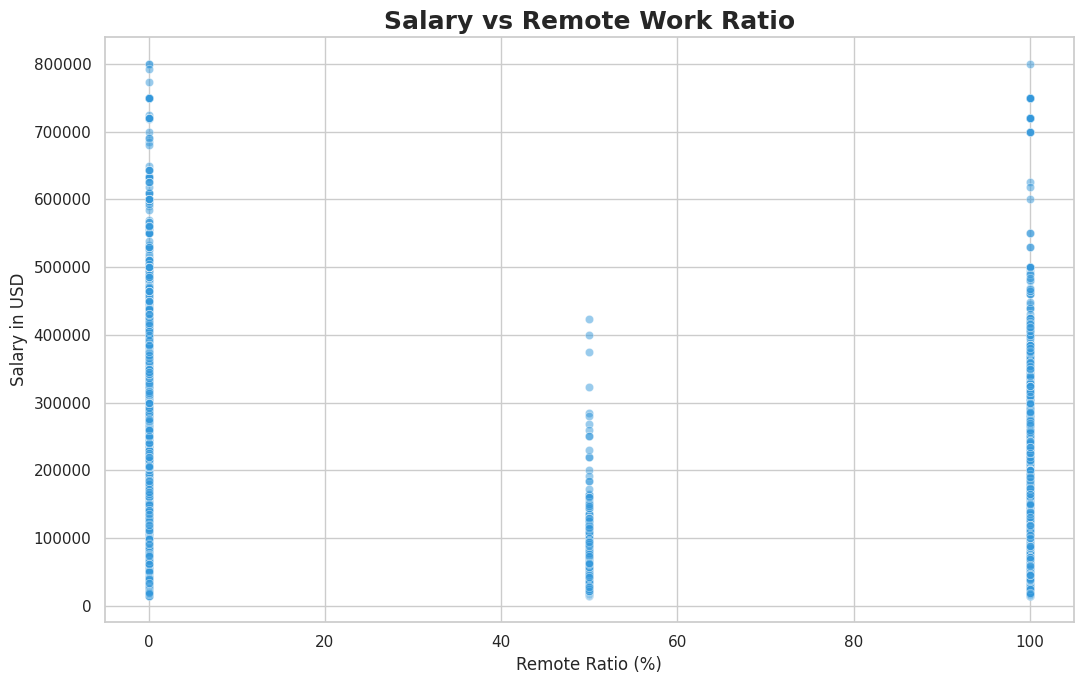

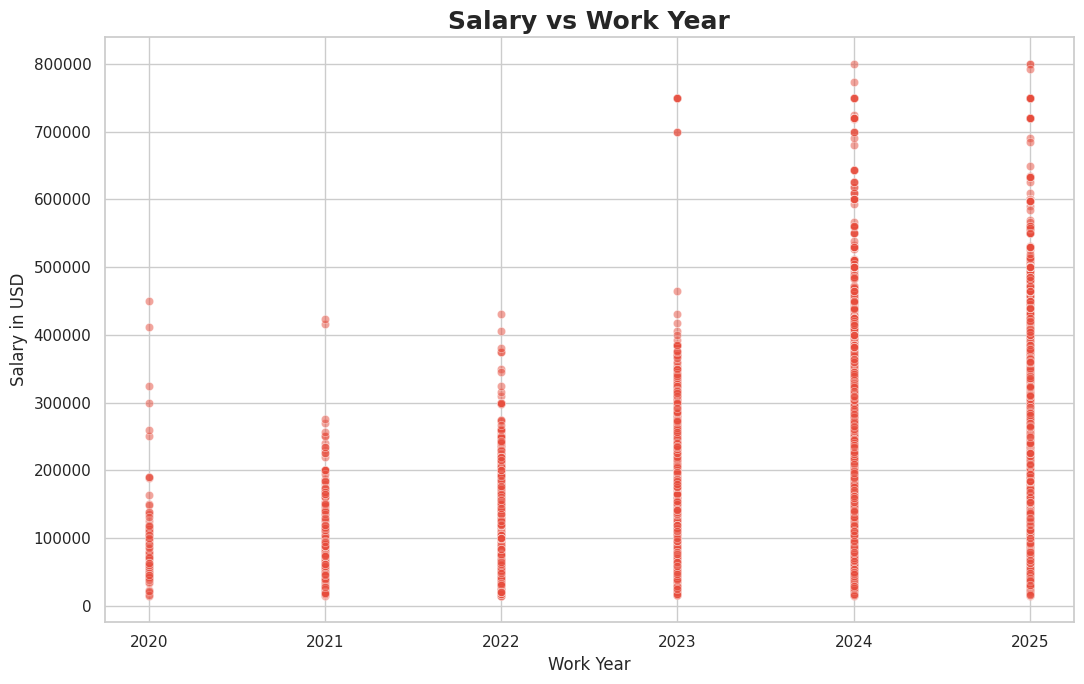

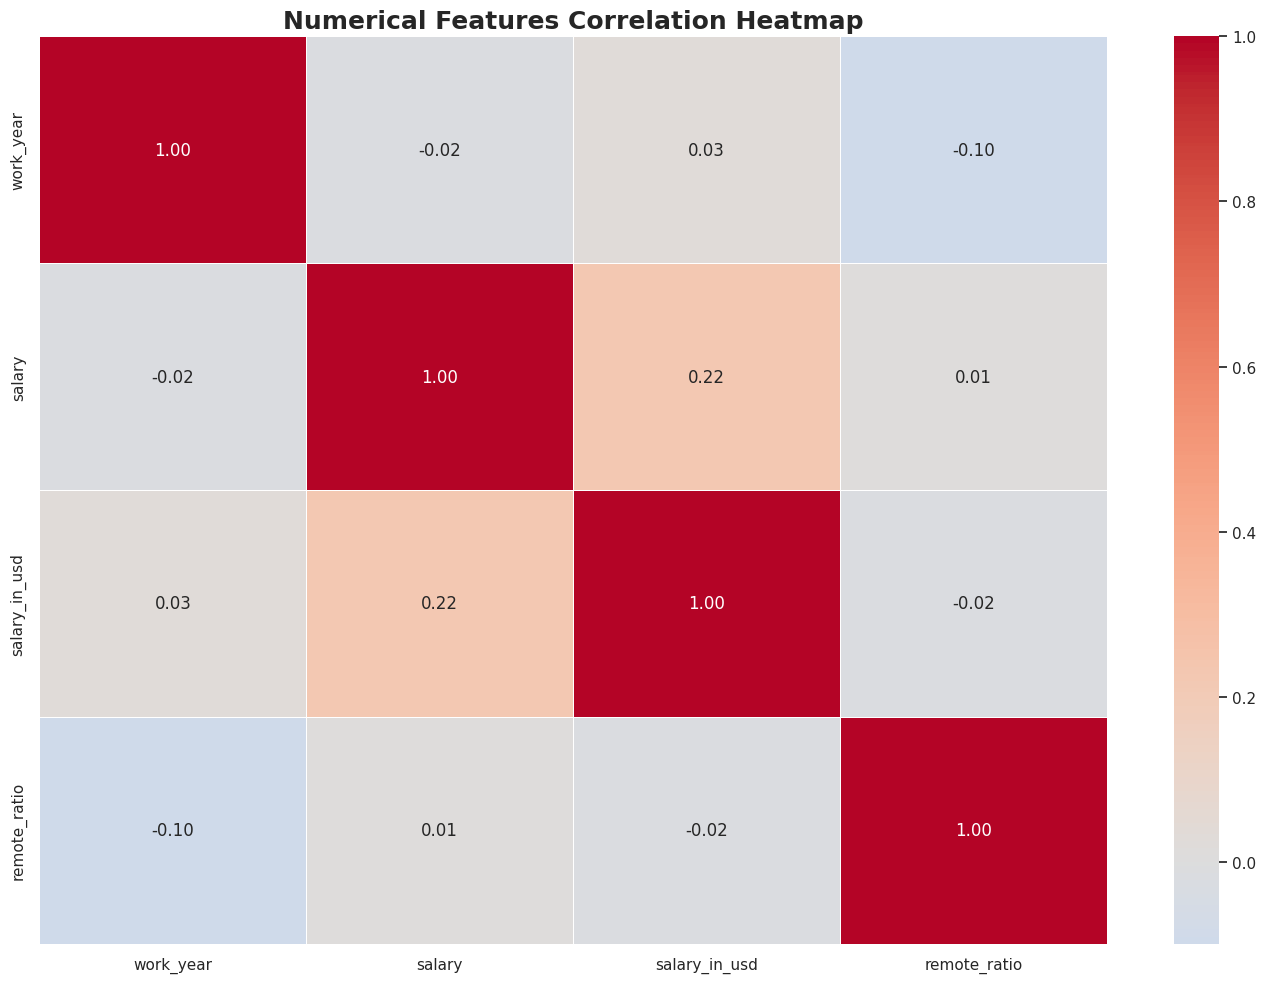

<Figure size 1200x700 with 0 Axes>

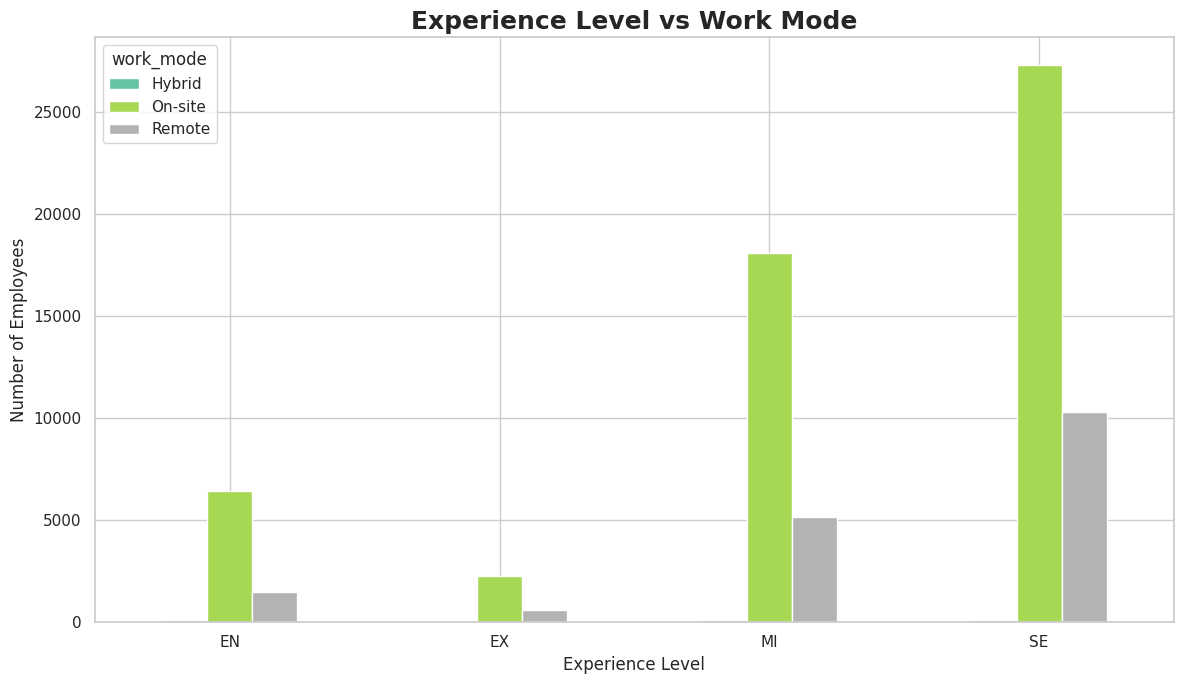

<Figure size 1200x700 with 0 Axes>

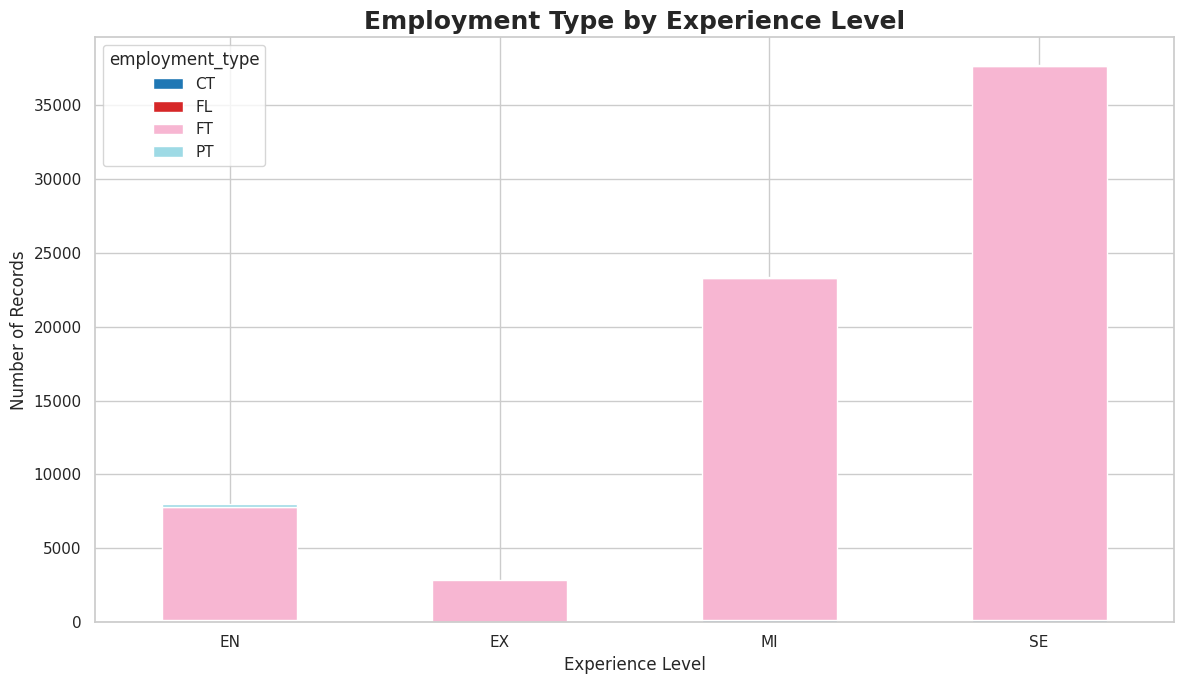

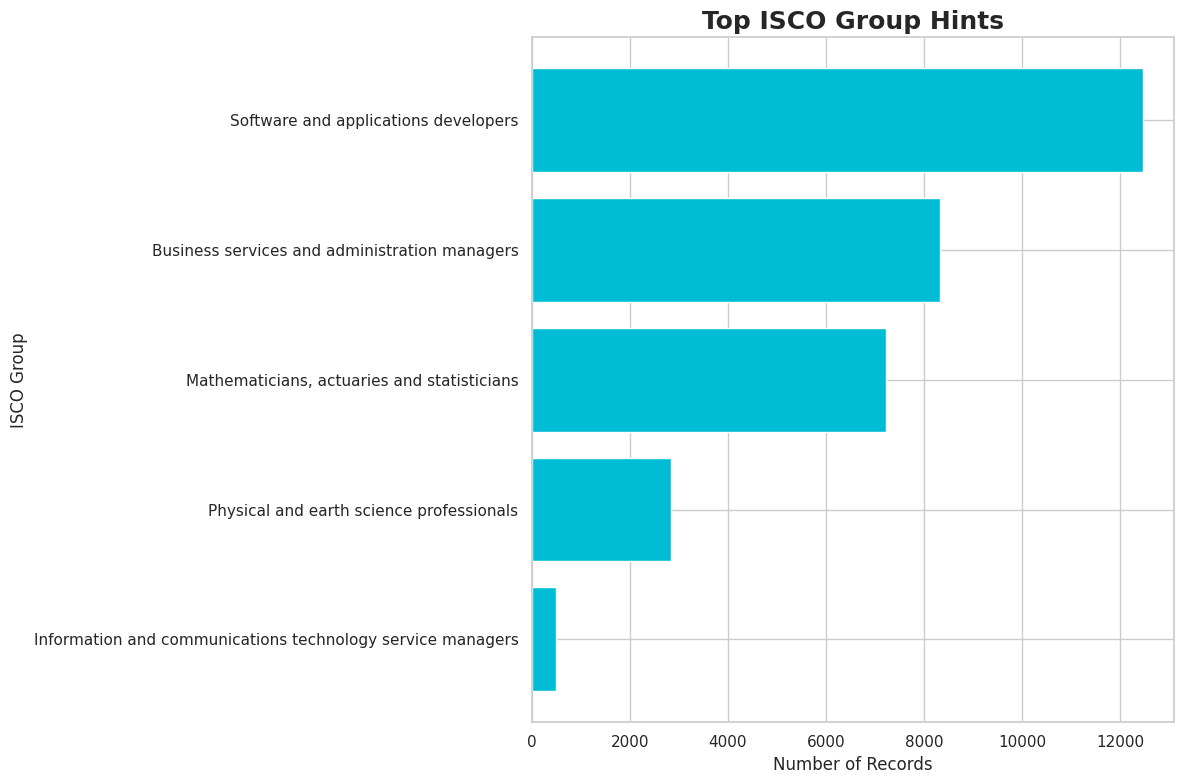

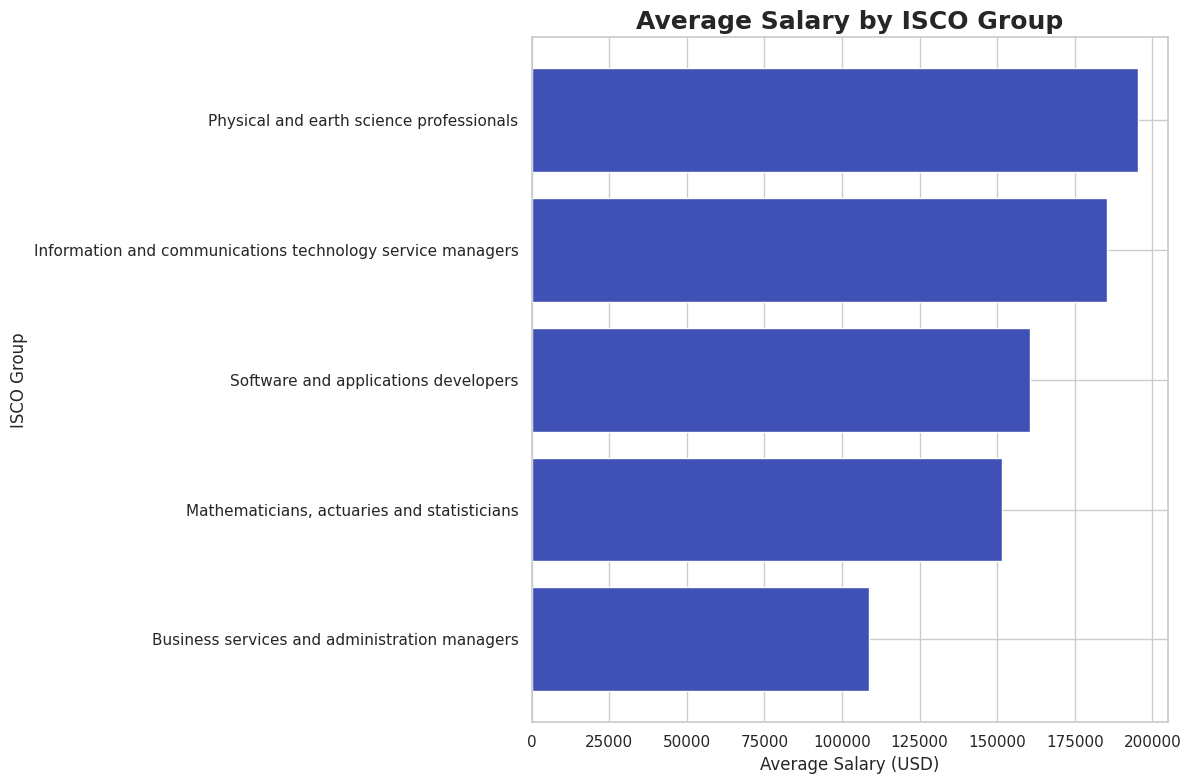

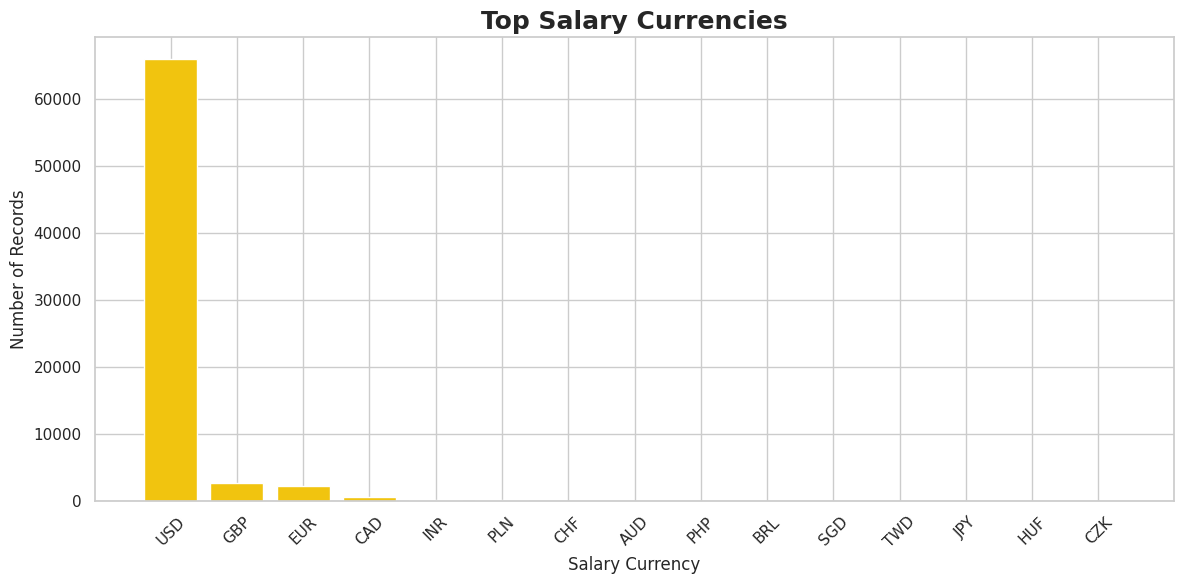



DATASET SUMMARY
Total Records       : 71,913
Total Columns       : 17
Average Salary      : $151,161.25
Median Salary       : $138,750.00
Minimum Salary      : $15,000.00
Maximum Salary      : $800,000.00
Most Common Job     : Data Scientist
Most Common Exp.    : SE
Most Common Work    : On-site

Visualization completed successfully.


In [13]:
# Display settings
pd.set_option("display.max_columns", None)

# Professional plotting style
sns.set_theme(style="whitegrid")

# Different color palettes
COLORS = {
    "blue": "#3498DB",
    "purple": "#8E44AD",
    "green": "#27AE60",
    "orange": "#E67E22",
    "red": "#E74C3C",
    "cyan": "#00BCD4",
    "pink": "#E91E63",
    "yellow": "#F1C40F",
    "teal": "#009688",
    "indigo": "#3F51B5"
}

# ------------------------------------------------------------
# 2. CHECK DATA
# ------------------------------------------------------------

print("=" * 70)
print("DATASET INFORMATION")
print("=" * 70)

print("\nShape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())


# ------------------------------------------------------------
# 3. DATA CLEANING
# ------------------------------------------------------------

# Make a copy
data = df.copy()

# Remove completely empty rows
data = data.dropna(how="all")

# Remove duplicate rows
data = data.drop_duplicates()

# Convert salary columns to numeric where possible
for col in ["salary", "salary_in_usd", "remote_ratio", "work_year"]:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors="coerce")

print("\nCleaned Shape:", data.shape)


# ============================================================
# 4. NUMERICAL COLUMN DISTRIBUTIONS
# ============================================================

numeric_cols = data.select_dtypes(include=np.number).columns.tolist()

print("\nNumeric Columns:")
print(numeric_cols)

for col in numeric_cols:

    plt.figure(figsize=(10, 5))

    sns.histplot(
        data[col].dropna(),
        kde=True,
        bins=30,
        color=COLORS["blue"]
    )

    plt.title(
        f"Distribution of {col.replace('_', ' ').title()}",
        fontsize=16,
        fontweight="bold"
    )

    plt.xlabel(col.replace("_", " ").title())
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()


# ============================================================
# 5. SALARY IN USD DISTRIBUTION
# ============================================================

if "salary_in_usd" in data.columns:

    plt.figure(figsize=(12, 6))

    sns.histplot(
        data=data,
        x="salary_in_usd",
        bins=40,
        kde=True,
        color=COLORS["purple"]
    )

    plt.axvline(
        data["salary_in_usd"].median(),
        linestyle="--",
        linewidth=2,
        color=COLORS["red"],
        label=f"Median: ${data['salary_in_usd'].median():,.0f}"
    )

    plt.axvline(
        data["salary_in_usd"].mean(),
        linestyle="--",
        linewidth=2,
        color=COLORS["green"],
        label=f"Mean: ${data['salary_in_usd'].mean():,.0f}"
    )

    plt.title(
        "Salary Distribution in USD",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Salary in USD")
    plt.ylabel("Number of Employees")
    plt.legend()

    plt.tight_layout()
    plt.show()


# ============================================================
# 6. SALARY BOXPLOT
# ============================================================

if "salary_in_usd" in data.columns:

    plt.figure(figsize=(12, 4))

    sns.boxplot(
        x=data["salary_in_usd"],
        color=COLORS["orange"]
    )

    plt.title(
        "Salary in USD - Boxplot",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel("Salary in USD")

    plt.tight_layout()
    plt.show()


# ============================================================
# 7. SALARY BY EXPERIENCE LEVEL
# ============================================================

if {"experience_level", "salary_in_usd"}.issubset(data.columns):

    plt.figure(figsize=(12, 6))

    order = (
        data.groupby("experience_level")["salary_in_usd"]
        .median()
        .sort_values()
        .index
    )

    sns.boxplot(
        data=data,
        x="experience_level",
        y="salary_in_usd",
        order=order,
        color=COLORS["cyan"]
    )

    plt.title(
        "Salary Distribution by Experience Level",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Experience Level")
    plt.ylabel("Salary in USD")

    plt.tight_layout()
    plt.show()


# ============================================================
# 8. AVERAGE SALARY BY EXPERIENCE LEVEL
# ============================================================

if {"experience_level", "salary_in_usd"}.issubset(data.columns):

    salary_exp = (
        data.groupby("experience_level")["salary_in_usd"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        salary_exp.index,
        salary_exp.values,
        color=[
            COLORS["purple"],
            COLORS["blue"],
            COLORS["green"],
            COLORS["orange"]
        ][:len(salary_exp)]
    )

    plt.title(
        "Average Salary by Experience Level",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Experience Level")
    plt.ylabel("Average Salary (USD)")

    for bar in bars:
        height = bar.get_height()

        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height,
            f"${height:,.0f}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 9. EMPLOYMENT TYPE DISTRIBUTION
# ============================================================

if "employment_type" in data.columns:

    counts = data["employment_type"].value_counts()

    plt.figure(figsize=(9, 7))

    plt.pie(
        counts.values,
        labels=counts.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=[
            COLORS["blue"],
            COLORS["orange"],
            COLORS["green"],
            COLORS["purple"],
            COLORS["red"]
        ][:len(counts)]
    )

    plt.title(
        "Employment Type Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 10. EXPERIENCE LEVEL DISTRIBUTION
# ============================================================

if "experience_level" in data.columns:

    exp_counts = data["experience_level"].value_counts()

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        exp_counts.index,
        exp_counts.values,
        color=[
            COLORS["purple"],
            COLORS["cyan"],
            COLORS["green"],
            COLORS["orange"]
        ][:len(exp_counts)]
    )

    plt.title(
        "Experience Level Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Experience Level")
    plt.ylabel("Number of Employees")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom",
            fontweight="bold"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 11. REMOTE WORK DISTRIBUTION
# ============================================================

if "remote_ratio" in data.columns:

    remote_counts = data["remote_ratio"].value_counts().sort_index()

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        remote_counts.index.astype(str),
        remote_counts.values,
        color=[
            COLORS["red"],
            COLORS["orange"],
            COLORS["green"]
        ][:len(remote_counts)]
    )

    plt.title(
        "Remote Work Ratio Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Remote Ratio (%)")
    plt.ylabel("Number of Employees")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 12. WORK MODE DISTRIBUTION
# ============================================================

if "work_mode" in data.columns:

    work_mode = data["work_mode"].value_counts()

    plt.figure(figsize=(9, 7))

    plt.pie(
        work_mode.values,
        labels=work_mode.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=[
            COLORS["teal"],
            COLORS["pink"],
            COLORS["yellow"],
            COLORS["indigo"]
        ][:len(work_mode)]
    )

    plt.title(
        "Work Mode Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 13. TOP 15 JOB TITLES
# ============================================================

if "job_title" in data.columns:

    top_jobs = data["job_title"].value_counts().head(15).sort_values()

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        top_jobs.index,
        top_jobs.values,
        color=COLORS["blue"]
    )

    plt.title(
        "Top 15 Most Common Job Titles",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Job Records")
    plt.ylabel("Job Title")

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" {int(bar.get_width()):,}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 14. TOP JOB TITLES BY AVERAGE SALARY
# ============================================================

if {"job_title", "salary_in_usd"}.issubset(data.columns):

    job_salary = (
        data.groupby("job_title")["salary_in_usd"]
        .agg(["mean", "count"])
    )

    # Keep jobs with at least 10 records
    job_salary = job_salary[job_salary["count"] >= 10]

    top_salary_jobs = (
        job_salary["mean"]
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        top_salary_jobs.index,
        top_salary_jobs.values,
        color=COLORS["green"]
    )

    plt.title(
        "Top 15 Job Titles by Average Salary",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Average Salary (USD)")
    plt.ylabel("Job Title")

    for bar in bars:
        plt.text(
            bar.get_width(),
            bar.get_y() + bar.get_height() / 2,
            f" ${bar.get_width():,.0f}",
            va="center"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 15. TOP 15 JOB TITLES BY MEDIAN SALARY
# ============================================================

if {"job_title", "salary_in_usd"}.issubset(data.columns):

    job_median = (
        data.groupby("job_title")["salary_in_usd"]
        .median()
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    plt.barh(
        job_median.index,
        job_median.values,
        color=COLORS["purple"]
    )

    plt.title(
        "Top 15 Job Titles by Median Salary",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Median Salary (USD)")
    plt.ylabel("Job Title")

    plt.tight_layout()
    plt.show()


# ============================================================
# 16. SALARY BY EMPLOYMENT TYPE
# ============================================================

if {"employment_type", "salary_in_usd"}.issubset(data.columns):

    plt.figure(figsize=(11, 6))

    sns.boxplot(
        data=data,
        x="employment_type",
        y="salary_in_usd",
        color=COLORS["pink"]
    )

    plt.title(
        "Salary Distribution by Employment Type",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Employment Type")
    plt.ylabel("Salary in USD")

    plt.tight_layout()
    plt.show()


# ============================================================
# 17. SALARY BY WORK MODE
# ============================================================

if {"work_mode", "salary_in_usd"}.issubset(data.columns):

    work_salary = (
        data.groupby("work_mode")["salary_in_usd"]
        .mean()
        .sort_values(ascending=False)
    )

    plt.figure(figsize=(10, 6))

    bars = plt.bar(
        work_salary.index,
        work_salary.values,
        color=[
            COLORS["orange"],
            COLORS["cyan"],
            COLORS["purple"],
            COLORS["green"]
        ][:len(work_salary)]
    )

    plt.title(
        "Average Salary by Work Mode",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Work Mode")
    plt.ylabel("Average Salary (USD)")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"${bar.get_height():,.0f}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 18. SALARY TREND BY WORK YEAR
# ============================================================

if {"work_year", "salary_in_usd"}.issubset(data.columns):

    yearly_salary = (
        data.groupby("work_year")["salary_in_usd"]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(12, 6))

    plt.plot(
        yearly_salary.index,
        yearly_salary.values,
        marker="o",
        linewidth=3,
        color=COLORS["red"]
    )

    plt.title(
        "Average Salary Trend by Work Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Work Year")
    plt.ylabel("Average Salary (USD)")

    plt.xticks(yearly_salary.index)

    plt.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()


# ============================================================
# 19. NUMBER OF JOB RECORDS BY YEAR
# ============================================================

if "work_year" in data.columns:

    year_counts = data["work_year"].value_counts().sort_index()

    plt.figure(figsize=(11, 6))

    bars = plt.bar(
        year_counts.index.astype(str),
        year_counts.values,
        color=COLORS["indigo"]
    )

    plt.title(
        "Number of Job Records by Work Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Work Year")
    plt.ylabel("Number of Records")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 20. COMPANY SIZE DISTRIBUTION
# ============================================================

if "company_size" in data.columns:

    company_size = data["company_size"].value_counts()

    plt.figure(figsize=(9, 7))

    plt.pie(
        company_size.values,
        labels=company_size.index,
        autopct="%1.1f%%",
        startangle=90,
        colors=[
            COLORS["blue"],
            COLORS["orange"],
            COLORS["green"],
            COLORS["purple"]
        ][:len(company_size)]
    )

    plt.title(
        "Company Size Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 21. SALARY BY COMPANY SIZE
# ============================================================

if {"company_size", "salary_in_usd"}.issubset(data.columns):

    plt.figure(figsize=(10, 6))

    sns.boxplot(
        data=data,
        x="company_size",
        y="salary_in_usd",
        color=COLORS["yellow"]
    )

    plt.title(
        "Salary Distribution by Company Size",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Company Size")
    plt.ylabel("Salary in USD")

    plt.tight_layout()
    plt.show()


# ============================================================
# 22. TOP 15 COMPANY LOCATIONS
# ============================================================

if "company_location" in data.columns:

    locations = data["company_location"].value_counts().head(15)

    plt.figure(figsize=(12, 7))

    bars = plt.bar(
        locations.index,
        locations.values,
        color=COLORS["teal"]
    )

    plt.title(
        "Top 15 Company Locations",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Company Location")
    plt.ylabel("Number of Companies / Records")

    plt.xticks(rotation=45, ha="right")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. TOP 15 EMPLOYEE RESIDENCES
# ============================================================

if "employee_residence" in data.columns:

    residence = data["employee_residence"].value_counts().head(15)

    plt.figure(figsize=(12, 7))

    bars = plt.bar(
        residence.index,
        residence.values,
        color=COLORS["orange"]
    )

    plt.title(
        "Top 15 Employee Residence Locations",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Employee Residence")
    plt.ylabel("Number of Employees")

    plt.xticks(rotation=45, ha="right")

    for bar in bars:
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height(),
            f"{int(bar.get_height()):,}",
            ha="center",
            va="bottom"
        )

    plt.tight_layout()
    plt.show()


# ============================================================
# 24. ROLE FAMILY DISTRIBUTION
# ============================================================

if "role_family" in data.columns:

    role_family = data["role_family"].value_counts().head(15)

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        role_family.index[::-1],
        role_family.values[::-1],
        color=COLORS["purple"]
    )

    plt.title(
        "Top Role Families",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Records")
    plt.ylabel("Role Family")

    plt.tight_layout()
    plt.show()


# ============================================================
# 25. ROLE FAMILY VS SALARY
# ============================================================

if {"role_family", "salary_in_usd"}.issubset(data.columns):

    role_salary = (
        data.groupby("role_family")["salary_in_usd"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    plt.barh(
        role_salary.index,
        role_salary.values,
        color=COLORS["green"]
    )

    plt.title(
        "Top Role Families by Average Salary",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Average Salary (USD)")
    plt.ylabel("Role Family")

    plt.tight_layout()
    plt.show()


# ============================================================
# 26. SALARY OUTLIER FLAG
# ============================================================

if "salary_outlier_flag" in data.columns:

    outliers = data["salary_outlier_flag"].value_counts()

    plt.figure(figsize=(9, 7))

    plt.pie(
        outliers.values,
        labels=outliers.index.astype(str),
        autopct="%1.1f%%",
        startangle=90,
        colors=[
            COLORS["green"],
            COLORS["red"],
            COLORS["orange"]
        ][:len(outliers)]
    )

    plt.title(
        "Salary Outlier Flag Distribution",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 27. OUTLIERS BY EXPERIENCE LEVEL
# ============================================================

if {"experience_level", "salary_outlier_flag"}.issubset(data.columns):

    outlier_exp = pd.crosstab(
        data["experience_level"],
        data["salary_outlier_flag"]
    )

    plt.figure(figsize=(11, 6))

    outlier_exp.plot(
        kind="bar",
        figsize=(11, 6),
        colormap="viridis"
    )

    plt.title(
        "Salary Outliers by Experience Level",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Experience Level")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


# ============================================================
# 28. SALARY VS REMOTE RATIO
# ============================================================

if {"remote_ratio", "salary_in_usd"}.issubset(data.columns):

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=data,
        x="remote_ratio",
        y="salary_in_usd",
        alpha=0.5,
        color=COLORS["blue"]
    )

    plt.title(
        "Salary vs Remote Work Ratio",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Remote Ratio (%)")
    plt.ylabel("Salary in USD")

    plt.tight_layout()
    plt.show()


# ============================================================
# 29. SALARY VS WORK YEAR
# ============================================================

if {"work_year", "salary_in_usd"}.issubset(data.columns):

    plt.figure(figsize=(11, 7))

    sns.scatterplot(
        data=data,
        x="work_year",
        y="salary_in_usd",
        alpha=0.5,
        color=COLORS["red"]
    )

    plt.title(
        "Salary vs Work Year",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Work Year")
    plt.ylabel("Salary in USD")

    plt.tight_layout()
    plt.show()


# ============================================================
# 30. CORRELATION HEATMAP
# ============================================================

numeric_data = data.select_dtypes(include=np.number)

if numeric_data.shape[1] >= 2:

    plt.figure(figsize=(14, 10))

    correlation = numeric_data.corr()

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        linewidths=0.5
    )

    plt.title(
        "Numerical Features Correlation Heatmap",
        fontsize=18,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 31. EXPERIENCE LEVEL × WORK MODE
# ============================================================

if {"experience_level", "work_mode"}.issubset(data.columns):

    cross_tab = pd.crosstab(
        data["experience_level"],
        data["work_mode"]
    )

    plt.figure(figsize=(12, 7))

    cross_tab.plot(
        kind="bar",
        figsize=(12, 7),
        colormap="Set2"
    )

    plt.title(
        "Experience Level vs Work Mode",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Experience Level")
    plt.ylabel("Number of Employees")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


# ============================================================
# 32. EMPLOYMENT TYPE × EXPERIENCE LEVEL
# ============================================================

if {"employment_type", "experience_level"}.issubset(data.columns):

    cross_tab = pd.crosstab(
        data["experience_level"],
        data["employment_type"]
    )

    plt.figure(figsize=(12, 7))

    cross_tab.plot(
        kind="bar",
        stacked=True,
        figsize=(12, 7),
        colormap="tab20"
    )

    plt.title(
        "Employment Type by Experience Level",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Experience Level")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()


# ============================================================
# 33. TOP ISCO GROUP HINT
# ============================================================

if "isco_group_hint" in data.columns:

    isco = data["isco_group_hint"].value_counts().head(15)

    plt.figure(figsize=(12, 8))

    bars = plt.barh(
        isco.index.astype(str)[::-1],
        isco.values[::-1],
        color=COLORS["cyan"]
    )

    plt.title(
        "Top ISCO Group Hints",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Number of Records")
    plt.ylabel("ISCO Group")

    plt.tight_layout()
    plt.show()


# ============================================================
# 34. SALARY BY ISCO GROUP
# ============================================================

if {"isco_group_hint", "salary_in_usd"}.issubset(data.columns):

    isco_salary = (
        data.groupby("isco_group_hint")["salary_in_usd"]
        .mean()
        .sort_values(ascending=False)
        .head(15)
        .sort_values()
    )

    plt.figure(figsize=(12, 8))

    plt.barh(
        isco_salary.index.astype(str),
        isco_salary.values,
        color=COLORS["indigo"]
    )

    plt.title(
        "Average Salary by ISCO Group",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Average Salary (USD)")
    plt.ylabel("ISCO Group")

    plt.tight_layout()
    plt.show()


# ============================================================
# 35. SALARY CURRENCY DISTRIBUTION
# ============================================================

if "salary_currency" in data.columns:

    currency = data["salary_currency"].value_counts().head(15)

    plt.figure(figsize=(12, 6))

    bars = plt.bar(
        currency.index,
        currency.values,
        color=COLORS["yellow"]
    )

    plt.title(
        "Top Salary Currencies",
        fontsize=18,
        fontweight="bold"
    )

    plt.xlabel("Salary Currency")
    plt.ylabel("Number of Records")

    plt.xticks(rotation=45)

    plt.tight_layout()
    plt.show()


# ============================================================
# 36. DASHBOARD-STYLE SUMMARY
# ============================================================

print("\n")
print("=" * 70)
print("DATASET SUMMARY")
print("=" * 70)

print(f"Total Records       : {len(data):,}")
print(f"Total Columns       : {data.shape[1]:,}")

if "salary_in_usd" in data.columns:

    print(
        f"Average Salary      : "
        f"${data['salary_in_usd'].mean():,.2f}"
    )

    print(
        f"Median Salary       : "
        f"${data['salary_in_usd'].median():,.2f}"
    )

    print(
        f"Minimum Salary      : "
        f"${data['salary_in_usd'].min():,.2f}"
    )

    print(
        f"Maximum Salary      : "
        f"${data['salary_in_usd'].max():,.2f}"
    )

if "job_title" in data.columns:

    print(
        f"Most Common Job     : "
        f"{data['job_title'].mode()[0]}"
    )

if "experience_level" in data.columns:

    print(
        f"Most Common Exp.    : "
        f"{data['experience_level'].mode()[0]}"
    )

if "work_mode" in data.columns:

    print(
        f"Most Common Work    : "
        f"{data['work_mode'].mode()[0]}"
    )

print("=" * 70)

print("\nVisualization completed successfully.")

## Feature engineering

DATASET INFORMATION
Dataset Shape: (71913, 17)

Columns:
['work_year', 'experience_level', 'employment_type', 'job_title', 'salary', 'salary_currency', 'salary_in_usd', 'employee_residence', 'remote_ratio', 'company_location', 'company_size', 'experience_level_label', 'employment_type_label', 'work_mode', 'salary_outlier_flag', 'role_family', 'isco_group_hint']

Data Types:
work_year                  int64
experience_level          object
employment_type           object
job_title                 object
salary                     int64
salary_currency           object
salary_in_usd              int64
employee_residence        object
remote_ratio               int64
company_location          object
company_size              object
experience_level_label    object
employment_type_label     object
work_mode                 object
salary_outlier_flag         bool
role_family               object
isco_group_hint           object
dtype: object

Missing Values:
work_year                     0

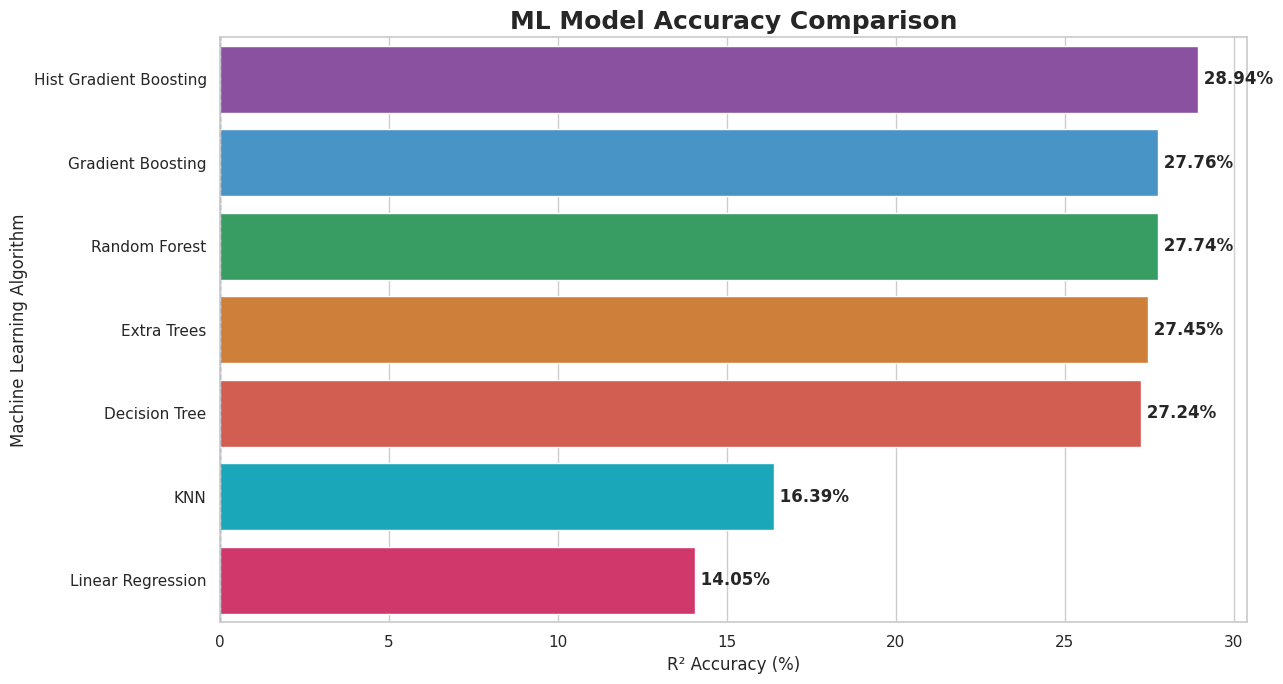

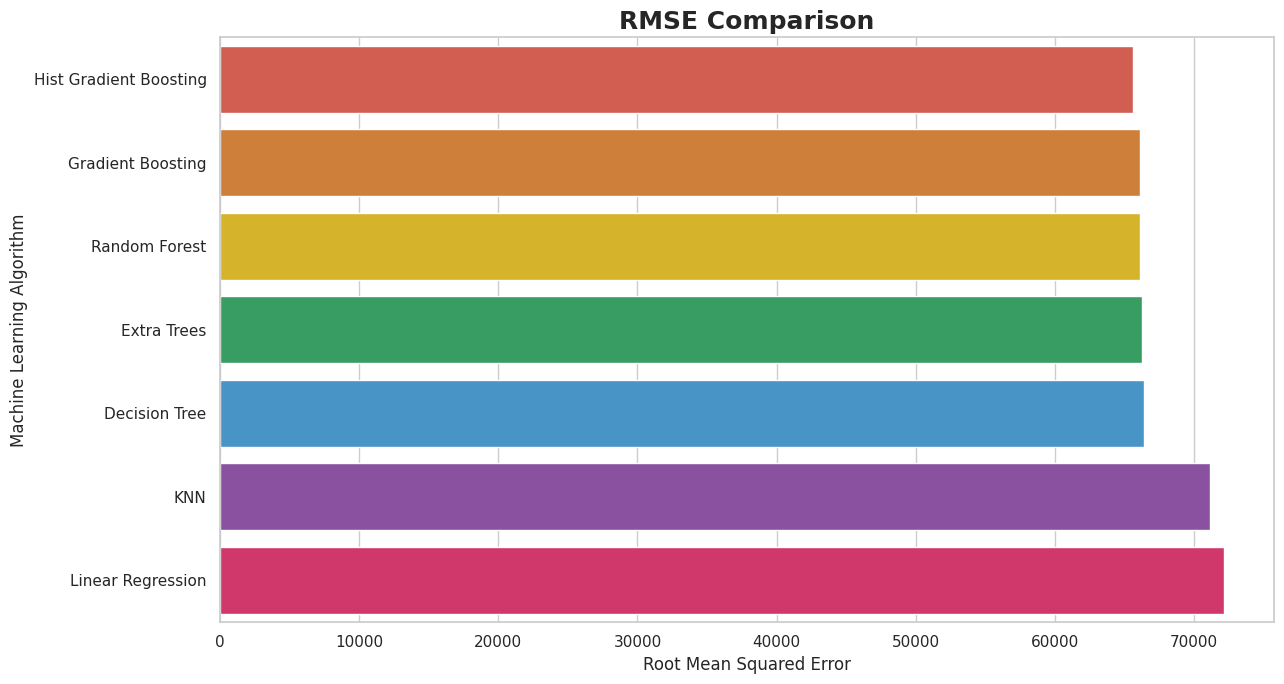

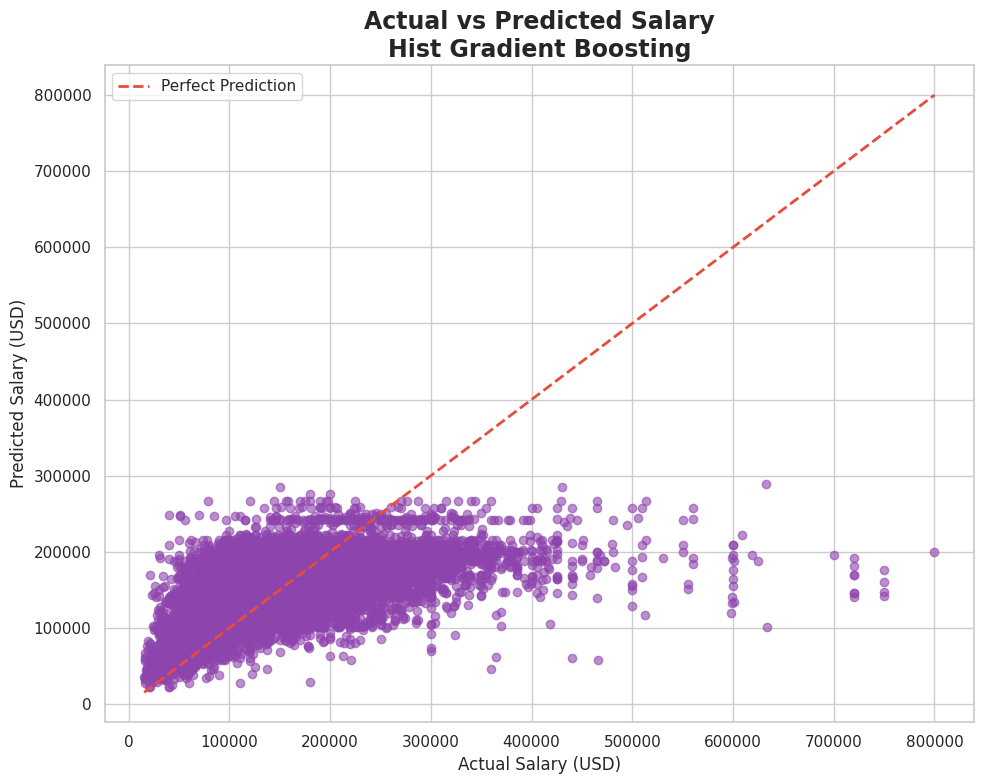

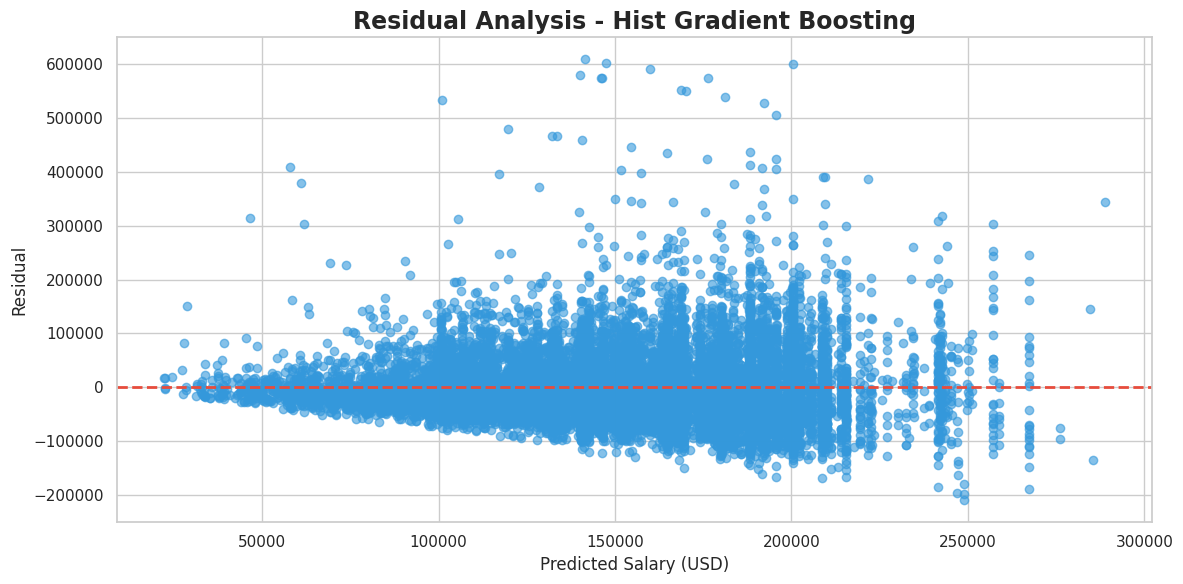



SAMPLE PREDICTIONS
 Actual Salary  Predicted Salary     Difference  Absolute Error
         90900     100810.721068   -9910.721068     9910.721068
        256470     191671.044975   64798.955025    64798.955025
        192986     209010.283684  -16024.283684    16024.283684
        185500     121084.968632   64415.031368    64415.031368
        122500     215455.600568  -92955.600568    92955.600568
        180000     101020.655349   78979.344651    78979.344651
         67500     167910.037352 -100410.037352   100410.037352
         61699     103780.205663  -42081.205663    42081.205663
         75084     132185.185623  -57101.185623    57101.185623
        142896     188371.768206  -45475.768206    45475.768206
        125000     113436.601152   11563.398848    11563.398848
        105100     142652.705400  -37552.705400    37552.705400
        135900     151967.321391  -16067.321391    16067.321391
        115384     131187.093983  -15803.093983    15803.093983
        220000     

In [14]:
# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# ML Algorithms
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    ExtraTreesRegressor,
    RandomForestRegressor,
    HistGradientBoostingRegressor
)

from sklearn.neighbors import KNeighborsRegressor

# Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")


data = df.copy()


# ============================================================
# 3. DISPLAY DATA INFORMATION
# ============================================================

print("=" * 80)
print("DATASET INFORMATION")
print("=" * 80)

print("Dataset Shape:", data.shape)

print("\nColumns:")
print(data.columns.tolist())

print("\nData Types:")
print(data.dtypes)

print("\nMissing Values:")
print(data.isnull().sum())


# ============================================================
# 4. REMOVE DUPLICATES
# ============================================================

data = data.drop_duplicates().reset_index(drop=True)

print("\nShape after removing duplicates:", data.shape)


# ============================================================
# 5. TARGET COLUMN
# ============================================================

TARGET = "salary_in_usd"

if TARGET not in data.columns:
    raise ValueError(
        f"Target column '{TARGET}' was not found in the dataset."
    )


# ============================================================
# 6. CONVERT TARGET TO NUMERIC
# ============================================================

data[TARGET] = pd.to_numeric(
    data[TARGET],
    errors="coerce"
)

# Remove rows where target is missing
data = data.dropna(subset=[TARGET]).reset_index(drop=True)



columns_to_drop = [
    TARGET,
    "salary",
    "salary_currency",
    "salary_outlier_flag",
    "experience_level_label",
    "employment_type_label"
]

columns_to_drop = [
    col for col in columns_to_drop
    if col in data.columns
]


# ============================================================
# 8. CREATE FEATURES AND TARGET
# ============================================================

X = data.drop(
    columns=columns_to_drop,
    errors="ignore"
)

y = data[TARGET]


print("\n")
print("=" * 80)
print("FEATURES")
print("=" * 80)

print(X.columns.tolist())

print("\nTarget:")
print(TARGET)


# ============================================================
# 9. HANDLE NUMERIC COLUMNS
# ============================================================

numeric_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

print("\nNumeric Columns:")
print(numeric_columns)


# Fill numerical missing values with median
for col in numeric_columns:

    X[col] = pd.to_numeric(
        X[col],
        errors="coerce"
    )

    X[col] = X[col].fillna(
        X[col].median()
    )


# ============================================================
# 10. LABEL ENCODING
# ============================================================

categorical_columns = X.select_dtypes(
    include=["object", "category", "bool"]
).columns.tolist()

print("\n")
print("=" * 80)
print("CATEGORICAL COLUMNS")
print("=" * 80)

print(categorical_columns)


# Dictionary to store encoders
label_encoders = {}


for col in categorical_columns:

    # Convert to string
    X[col] = X[col].astype(str)

    # Fill missing values
    X[col] = X[col].fillna("Unknown")

    # Create encoder
    encoder = LabelEncoder()

    # Encode
    X[col] = encoder.fit_transform(X[col])

    # Save encoder
    label_encoders[col] = encoder


# ============================================================
# 11. DISPLAY LABEL ENCODING RESULTS
# ============================================================

print("\n")
print("=" * 80)
print("LABEL ENCODING RESULTS")
print("=" * 80)

for col, encoder in label_encoders.items():

    print(f"\nColumn: {col}")

    mapping = dict(
        zip(
            encoder.classes_,
            encoder.transform(encoder.classes_)
        )
    )

    print(mapping)


# ============================================================
# 12. FINAL FEATURE CHECK
# ============================================================

print("\n")
print("=" * 80)
print("FINAL FEATURE DATA")
print("=" * 80)

print(X.head())

print("\nFinal Shape:", X.shape)

print("\nRemaining Missing Values:")
print(X.isnull().sum().sum())


# ============================================================
# 13. TRAIN TEST SPLIT
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)


print("\n")
print("=" * 80)
print("TRAIN TEST SPLIT")
print("=" * 80)

print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

print("\nTraining Data:", len(X_train))
print("Testing Data :", len(X_test))


# ============================================================
# 14. DEFINE ML ALGORITHMS
# ============================================================

models = {

    "Linear Regression":
        LinearRegression(),

    "Decision Tree":
        DecisionTreeRegressor(
            random_state=42,
            max_depth=15,
            min_samples_split=5
        ),

    "Random Forest":
        RandomForestRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=20,
            min_samples_split=2
        ),

    "Gradient Boosting":
        GradientBoostingRegressor(
            n_estimators=200,
            learning_rate=0.05,
            max_depth=4,
            random_state=42
        ),

    "Extra Trees":
        ExtraTreesRegressor(
            n_estimators=200,
            random_state=42,
            n_jobs=-1,
            max_depth=20,
            min_samples_split=2
        ),

    "KNN":
        KNeighborsRegressor(
            n_neighbors=5
        ),

    "Hist Gradient Boosting":
        HistGradientBoostingRegressor(
            max_iter=200,
            learning_rate=0.05,
            max_leaf_nodes=31,
            random_state=42
        )
}


# ============================================================
# 15. TRAIN ALL MODELS
# ============================================================

results = []

trained_models = {}

predictions = {}


print("\n")
print("=" * 80)
print("MODEL TRAINING")
print("=" * 80)


for name, model in models.items():

    print(f"\nTraining: {name}")

    # Train model
    model.fit(
        X_train,
        y_train
    )

    # Prediction
    y_pred = model.predict(
        X_test
    )

    # Metrics
    mae = mean_absolute_error(
        y_test,
        y_pred
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            y_pred
        )
    )

    r2 = r2_score(
        y_test,
        y_pred
    )

    # R2 as percentage
    accuracy_percentage = r2 * 100

    # Store
    results.append({
        "Model": name,
        "R2 Score": r2,
        "Accuracy (%)": accuracy_percentage,
        "MAE": mae,
        "RMSE": rmse
    })

    trained_models[name] = model
    predictions[name] = y_pred

    print(
        f"Accuracy (R²): {accuracy_percentage:.2f}%"
    )

    print(
        f"MAE: ${mae:,.2f}"
    )

    print(
        f"RMSE: ${rmse:,.2f}"
    )


# ============================================================
# 16. MODEL COMPARISON
# ============================================================

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="Accuracy (%)",
    ascending=False
).reset_index(drop=True)


print("\n")
print("=" * 80)
print("MODEL PERFORMANCE COMPARISON")
print("=" * 80)

print(
    results_df.to_string(
        index=False
    )
)


# ============================================================
# 17. BEST MODEL
# ============================================================

best_model_name = results_df.loc[
    0,
    "Model"
]

best_accuracy = results_df.loc[
    0,
    "Accuracy (%)"
]

best_mae = results_df.loc[
    0,
    "MAE"
]

best_rmse = results_df.loc[
    0,
    "RMSE"
]

best_r2 = results_df.loc[
    0,
    "R2 Score"
]

best_model = trained_models[
    best_model_name
]


print("\n")
print("=" * 80)
print("BEST MODEL")
print("=" * 80)

print(
    f"Best Model       : {best_model_name}"
)

print(
    f"R² Score         : {best_r2:.4f}"
)

print(
    f"Accuracy         : {best_accuracy:.2f}%"
)

print(
    f"MAE              : ${best_mae:,.2f}"
)

print(
    f"RMSE             : ${best_rmse:,.2f}"
)


# ============================================================
# 18. ACCURACY BAR CHART
# ============================================================

plt.figure(
    figsize=(13, 7)
)

sns.barplot(
    data=results_df,
    x="Accuracy (%)",
    y="Model",
    hue="Model",
    palette=[
        "#8E44AD",
        "#3498DB",
        "#27AE60",
        "#E67E22",
        "#E74C3C",
        "#00BCD4",
        "#E91E63"
    ][:len(results_df)],
    legend=False
)

plt.title(
    "ML Model Accuracy Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "R² Accuracy (%)"
)

plt.ylabel(
    "Machine Learning Algorithm"
)

plt.axvline(
    0,
    linestyle="--",
    linewidth=1
)

# Add values
for i, value in enumerate(
    results_df["Accuracy (%)"]
):

    plt.text(
        value,
        i,
        f" {value:.2f}%",
        va="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()


# ============================================================
# 19. RMSE COMPARISON
# ============================================================

plt.figure(
    figsize=(13, 7)
)

sns.barplot(
    data=results_df,
    x="RMSE",
    y="Model",
    hue="Model",
    palette=[
        "#E74C3C",
        "#E67E22",
        "#F1C40F",
        "#27AE60",
        "#3498DB",
        "#8E44AD",
        "#E91E63"
    ][:len(results_df)],
    legend=False
)

plt.title(
    "RMSE Comparison",
    fontsize=18,
    fontweight="bold"
)

plt.xlabel(
    "Root Mean Squared Error"
)

plt.ylabel(
    "Machine Learning Algorithm"
)

plt.tight_layout()
plt.show()


# ============================================================
# 20. ACTUAL VS PREDICTED - BEST MODEL
# ============================================================

best_predictions = predictions[
    best_model_name
]

plt.figure(
    figsize=(10, 8)
)

plt.scatter(
    y_test,
    best_predictions,
    alpha=0.6,
    color="#8E44AD"
)

# Perfect prediction line
minimum = min(
    y_test.min(),
    best_predictions.min()
)

maximum = max(
    y_test.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    color="#E74C3C",
    linestyle="--",
    linewidth=2,
    label="Perfect Prediction"
)

plt.title(
    f"Actual vs Predicted Salary\n{best_model_name}",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Actual Salary (USD)"
)

plt.ylabel(
    "Predicted Salary (USD)"
)

plt.legend()

plt.tight_layout()
plt.show()


# ============================================================
# 21. RESIDUAL ANALYSIS
# ============================================================

residuals = (
    y_test - best_predictions
)

plt.figure(
    figsize=(12, 6)
)

plt.scatter(
    best_predictions,
    residuals,
    alpha=0.6,
    color="#3498DB"
)

plt.axhline(
    0,
    color="#E74C3C",
    linestyle="--",
    linewidth=2
)

plt.title(
    f"Residual Analysis - {best_model_name}",
    fontsize=17,
    fontweight="bold"
)

plt.xlabel(
    "Predicted Salary (USD)"
)

plt.ylabel(
    "Residual"
)

plt.tight_layout()
plt.show()


# ============================================================
# 22. FEATURE IMPORTANCE
# ============================================================

if hasattr(
    best_model,
    "feature_importances_"
):

    importance_df = pd.DataFrame({

        "Feature":
            X.columns,

        "Importance":
            best_model.feature_importances_

    })

    importance_df = (
        importance_df
        .sort_values(
            by="Importance",
            ascending=False
        )
        .head(15)
    )

    print("\n")
    print("=" * 80)
    print("TOP 15 IMPORTANT FEATURES")
    print("=" * 80)

    print(
        importance_df.to_string(
            index=False
        )
    )


    plt.figure(
        figsize=(12, 8)
    )

    sns.barplot(
        data=importance_df,
        x="Importance",
        y="Feature",
        hue="Feature",
        palette="viridis",
        legend=False
    )

    plt.title(
        f"Top 15 Feature Importance\n{best_model_name}",
        fontsize=17,
        fontweight="bold"
    )

    plt.xlabel(
        "Importance"
    )

    plt.ylabel(
        "Feature"
    )

    plt.tight_layout()
    plt.show()


# ============================================================
# 23. PREDICTION SAMPLE
# ============================================================

prediction_table = pd.DataFrame({

    "Actual Salary":
        y_test.values,

    "Predicted Salary":
        best_predictions,

    "Difference":
        y_test.values - best_predictions

})

prediction_table["Absolute Error"] = (
    prediction_table["Difference"].abs()
)

print("\n")
print("=" * 80)
print("SAMPLE PREDICTIONS")
print("=" * 80)

print(
    prediction_table
    .head(20)
    .to_string(index=False)
)


# ============================================================
# 24. FINAL SUMMARY
# ============================================================

print("\n")
print("=" * 80)
print("FINAL ML SUMMARY")
print("=" * 80)

print(
    f"Dataset Records      : {len(data):,}"
)

print(
    f"Total Features       : {X.shape[1]}"
)

print(
    f"Training Records     : {len(X_train):,}"
)

print(
    f"Testing Records      : {len(X_test):,}"
)

print(
    f"Models Tested        : {len(models)}"
)

print(
    f"Best Algorithm       : {best_model_name}"
)

print(
    f"Best Accuracy (R²)   : {best_accuracy:.2f}%"
)

print(
    f"Best R² Score        : {best_r2:.4f}"
)

print(
    f"Best MAE             : ${best_mae:,.2f}"
)

print(
    f"Best RMSE            : ${best_rmse:,.2f}"
)

print("=" * 80)

print("\nMachine Learning Pipeline Completed Successfully!")


## Thank you..pls upvote!!!!!!!!!